<div style="border-left: 5px solid #1f4e79; padding: 16px 20px; background-color: #f8fafc; border: 1px solid #d9e2ec; border-radius: 6px; margin-bottom: 24px; font-family: Arial, sans-serif;">
  <h1 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 28px;">Notebook 03 — Définition des variables duattaché aux biens_B1</h1>
  <p style="margin: 0; color: #4b5563; font-size: 15px; line-height: 1.55;">construction des variables descriptives du bien à partir des mutations résidentielles nettoyées. Rôle dans le pipeline Ce notebook transforme le socle résidentiel nettoyé en une base de variables exploitables pour l’analyse immobilière et les étapes de modélisation. Il formalise la cible  prix/m² , les variables de surface, les variables de typologie, les dimensions temporelles et les indicateurs de contrôle qualité. Entrée :  mutations résidentielles nettoyées produites par le notebook précédent. Traitements :  création de variables, traçabilité via registre, contrôles qualité, diagnostics graphiques et segmentation des sorties selon leur usage. Sortie :  jeux de données enrichis transmis aux notebooks suivants, notamment la base complète, les variables candidates et les vues compatibles avec une logique de modélisation.</p>
</div>

In [ ]:
# Bibliothèques standard
from pathlib import Path
import json
import warnings
from datetime import datetime

# Bibliothèques tierces
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Options d'affichage : colonnes larges et format décimal uniforme
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
warnings.filterwarnings("ignore", category=FutureWarning)

# Localisation de la racine projet.
#
# Le notebook est conçu pour être exécuté :
# - depuis le dossier racine du projet,
# - ou depuis le dossier notebooks.
#
# Cette logique évite d'utiliser un chemin absolu local
# et rend le notebook plus portable.
CURRENT_DIR = Path.cwd().resolve()

PROJECT_ROOT = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name.lower() == "notebooks"
    else CURRENT_DIR
)

# Répertoires de travail utilisés dans le notebook.
PATHS = {
    "raw": PROJECT_ROOT / "data" / "raw",
    "external": PROJECT_ROOT / "data" / "external",
    "interim": PROJECT_ROOT / "data" / "interim",
    "processed": PROJECT_ROOT / "data" / "processed",
    "reports": PROJECT_ROOT / "outputs" / "tables",
    "figures": PROJECT_ROOT / "outputs" / "figures",
}

# Création des dossiers de sortie si nécessaire.
for p in PATHS.values():
    p.mkdir(parents=True, exist_ok=True)

FIGURE_DIR = PATHS["figures"]

# Entrée / sortie canoniques du notebook.
INPUT_PATH = PATHS["processed"] / "df_mutations_residentielles_nettoyees.parquet"
OUTPUT_PATH = PATHS["processed"] / "df_biens_residentiels_variables.parquet"

# Alias conservés pour compatibilité avec les cellules existantes du notebook.
input_path = INPUT_PATH
output_full = OUTPUT_PATH

# Vérification de la présence du fichier produit par le notebook précédent.
if not INPUT_PATH.exists():
    raise FileNotFoundError(
        "Fichier d'entrée introuvable. "
        "Attendu : data/processed/df_mutations_residentielles_nettoyees.parquet"
    )

# Horodatage de début d'exécution pour le manifest de sortie.
RUN_TIMESTAMP = datetime.now().isoformat(timespec="seconds")

print(f"Racine projet : {PROJECT_ROOT}")
print(f"Input utilisé : {INPUT_PATH}")
print(f"Output principal : {OUTPUT_PATH}")
print(f"Dossier figures : {FIGURE_DIR}")

Racine projet : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE
Input utilisé : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_mutations_residentielles_nettoyees.parquet
Output principal : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_biens_residentiels_variables.parquet
Dossier figures : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\figures


In [3]:
# Chargement du dataset nettoye produit par le notebook 00_02
df = pd.read_parquet(input_path)
print(f"Shape initiale : {df.shape[0]:,} lignes | {df.shape[1]:,} colonnes")
display(df.head())

# Mapping explicite des colonnes structurantes attendues dans ce fichier
COL = {
    "identifiant_mutation": "id_mutation",
    "valeur_fonciere": "valeur_fonciere",
    "surface_reference": "surface_reference",
    "date_mutation": "date_mutation",
}

print("Colonnes structurantes utilisees :")
for role, col in COL.items():
    print(f"- {role}: {col}")


Shape initiale : 3,925,350 lignes | 62 colonnes


,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,code_commune,nom_commune,code_departement,longitude,latitude,nb_lignes,nb_locaux,nb_appartements,nb_maisons,nb_dependances,surface_bati_totale,surface_terrain_totale,nb_pieces_total,nombre_lots_total,surface_carrez_totale,has_bati,has_terrain,has_imm_special,nb_seg_terrain_a_batir,nb_seg_agricole,nb_seg_agrement,nb_seg_bois_landes,nb_seg_sols,nb_seg_autre,nb_logements,has_logement,has_dependance,mutation_simple_logement,mutation_multiple_logements,ratio_bati_terrain_mutation,type_marche_mutation,type_mutation_economique,avec_dependances,categorie_logement,sous_categorie_logement,type_bien,surface_reference,source_surface_reference,surface_terrain_reference,prix_m2,prix_par_piece,ratio_bati_terrain,flag_valeur_valide,flag_surface_reference_valide,flag_prix_m2_valide,flag_qualite_globale,flag_residentiel,flag_surface_non_positive,flag_valeur_non_positive,flag_prix_m2_non_positif,flag_outlier_valeur_fonciere,flag_outlier_surface_reference,flag_outlier_prix_m2,flag_outlier,prix_m2_recalcule,flag_ecart_prix_m2_10pct,annee_mutation
0,2021-1,2021-01-05,1,Vente,"185,000.000",1426,Val-Revermont,1,5.386,46.327,2,2,0,1,1,97.000,"4,820.000",5.000,0,NaN,True,True,False,0,0,0,0,2,0,1,True,True,True,False,0.020,marche_secondaire_residentiel,maison,True,Maison,Maison moyenne (80-120 m²),Maison,97.000,bati,"4,820.000","1,907.216","37,000.000",0.020,True,True,True,True,True,False,False,False,False,False,False,False,"1,907.216",False,2021
1,2021-10,2021-01-08,1,Vente,"185,000.000",1289,Péronnas,1,5.210,46.188,1,1,0,1,0,100.000,703.000,4.000,0,NaN,True,True,False,0,0,0,0,1,0,1,True,False,True,False,0.142,marche_secondaire_residentiel,maison,False,Maison,Maison moyenne (80-120 m²),Maison,100.000,bati,703.000,"1,850.000","46,250.000",0.142,True,True,True,True,True,False,False,False,False,False,False,False,"1,850.000",False,2021
2,2021-1000,2021-04-01,1,Vente,"72,150.000",1053,Bourg-en-Bresse,1,5.229,46.213,2,2,1,0,1,86.000,NaN,4.000,4,174.480,True,False,False,0,0,0,0,0,2,1,True,True,True,False,NaN,marche_secondaire_residentiel,appartement,True,Appartement,Appartement T4,Appartement,174.480,carrez,NaN,413.514,"18,037.500",NaN,True,True,True,True,True,False,False,False,False,False,False,False,413.514,False,2021
3,2021-10000,2021-03-03,1,Vente,"51,500.000",1185,Plateau d'Hauteville,1,5.611,45.949,3,1,0,1,0,70.000,483.000,3.000,0,NaN,True,True,False,0,0,0,1,2,0,1,True,False,True,False,0.145,marche_secondaire_residentiel,maison,False,Maison,Petite maison (<=80 m²),Maison,70.000,bati,483.000,735.714,"17,166.667",0.145,True,True,True,True,True,False,False,False,False,False,False,False,735.714,False,2021
4,2021-1000001,2021-12-10,1,Vente,"45,000.000",59122,Cambrai,59,3.231,50.173,1,1,0,1,0,70.000,65.000,5.000,0,NaN,True,True,False,0,0,0,0,1,0,1,True,False,True,False,1.077,marche_secondaire_residentiel,maison,False,Maison,Petite maison (<=80 m²),Maison,70.000,bati,65.000,642.857,"9,000.000",1.077,True,True,True,True,True,False,False,False,False,False,False,False,642.857,False,2021


Colonnes structurantes utilisees :
- identifiant_mutation: id_mutation
- valeur_fonciere: valeur_fonciere
- surface_reference: surface_reference
- date_mutation: date_mutation


In [ ]:
# Création d'un Registre de variables créées dans le notebook.
#
# Chaque nouvelle variable est documentée afin de :
# - tracer son origine,
# - décrire son usage analytique,
# - identifier les risques de fuite de cible,
# - et distinguer les variables exploitables en modélisation.
#
# Cette logique facilite :
# - la reproductibilité,
# - la gouvernance des features,
# - et la préparation de futurs pipelines ML.


def add_feature(
    registry,
    name,
    family,
    description,
    model_safe_raw=True,
    usage="model_safe_raw",
    leakage_risk="faible",
    source="créée 00_03",
    train_transform_required=False,
):
    """
    Ajoute une variable au registre analytique.

    Paramètres :
    - registry : liste contenant le dictionnaire des variables
    - name : nom de la variable
    - family : famille métier/statistique
    - description : rôle de la variable
    - usage : usage recommandé
    - leakage_risk : niveau de risque de fuite de cible
    - source : origine de création
    - train_transform_required :
      True si la transformation doit être apprise sur train uniquement
    """

    registry.append({
        "variable": name,
        "famille": family,
        "description": description,
        "usage": usage,
        "model_safe_raw": bool(model_safe_raw),
        "train_transform_required": bool(train_transform_required),
        "leakage_risk": leakage_risk,
        "source": source,
    })

In [ ]:
# Fonctions utilitaires numériques.
#
# Ces fonctions sécurisent :
# - les calculs de ratios,
# - les divisions,
# - et certaines transformations exploratoires.
#
# Elles évitent notamment :
# - les divisions par zéro,
# - les valeurs infinies,
# - et certaines anomalies numériques.


def safe_divide(num, den):
    """
    Division sécurisée.

    Remplace les zéros du dénominateur par NaN
    afin d'éviter les divisions par zéro.

    Les valeurs infinies éventuelles sont ensuite neutralisées.
    """

    num = pd.to_numeric(num, errors="coerce")
    den = pd.to_numeric(den, errors="coerce")

    out = num / den.replace({0: np.nan})

    return out.replace([np.inf, -np.inf], np.nan)


def winsorize_series(s, low=0.01, high=0.99):
    """
    Winsorisation exploratoire d'une série.

    Les valeurs extrêmes sont plafonnées
    selon les quantiles définis.

    Attention :
    cette transformation ne doit pas être utilisée directement
    en modélisation sans apprentissage des seuils sur le train.
    """

    s = pd.to_numeric(s, errors="coerce")

    # Calcul des quantiles bas et haut.
    q_low, q_high = s.quantile([low, high])

    # Série bornée.
    clipped = s.clip(q_low, q_high)

    # Paramètres sauvegardés pour traçabilité.
    params = {
        "low": float(q_low),
        "high": float(q_high),
        "low_q": low,
        "high_q": high,
    }

    return clipped, params

In [ ]:
# Fonctions de visualisation standardisées.
#
# Ces fonctions :
# - homogénéisent les graphiques du notebook,
# - facilitent l'export PNG,
# - et évitent la répétition de code matplotlib.


def save_current_figure(filename):
    """
    Sauvegarde la figure matplotlib courante.

    La figure est :
    - exportée dans FIGURE_DIR,
    - affichée dans le notebook,
    - puis le chemin est retourné.
    """

    path = FIGURE_DIR / filename

    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")

    plt.show()

    return path


def plot_hist(series, title, xlabel, bins=60, filename=None):
    """
    Histogramme simple avec export optionnel.
    """

    plt.figure(figsize=(9, 4.5))

    plt.hist(series.dropna(), bins=bins)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Nombre d'observations")

    if filename:
        return save_current_figure(filename)

    plt.tight_layout()
    plt.show()

    return None


def plot_box_by_category(
    data,
    value_col,
    category_col,
    title,
    max_categories=12,
    filename=None
):
    """
    Boxplot d'une variable numérique par catégorie.

    Seules les catégories les plus fréquentes sont conservées
    afin d'améliorer la lisibilité.
    """

    tmp = data[[value_col, category_col]].dropna().copy()

    if tmp.empty:
        print(
            f"Graphique ignoré : "
            f"données insuffisantes pour "
            f"{value_col} / {category_col}"
        )
        return None

    # Catégories les plus fréquentes.
    order = (
        tmp[category_col]
        .value_counts()
        .head(max_categories)
        .index
        .tolist()
    )

    tmp = tmp[tmp[category_col].isin(order)]

    groups = [
        tmp.loc[tmp[category_col] == cat, value_col]
        .dropna()
        .values
        for cat in order
    ]

    plt.figure(figsize=(10, 5))

    plt.boxplot(
        groups,
        labels=order,
        showfliers=False
    )

    plt.title(title)
    plt.xlabel(category_col)
    plt.ylabel(value_col)

    plt.xticks(rotation=35, ha="right")

    if filename:
        return save_current_figure(filename)

    plt.tight_layout()
    plt.show()

    return None

In [ ]:
# Fonction centralisée de contrôle qualité.
#
# Chaque contrôle produit :
# - un taux de conformité,
# - un statut OK / WARNING / ERROR,
# - et une description interprétable.
#
# Cette logique permet de documenter
# la qualité des données à chaque étape.


def add_quality_check(
    checks,
    controle,
    condition,
    severity="warning",
    threshold=1.0,
    description=""
):
    """
    Ajoute un contrôle qualité au registre global.
    """

    valid = (
        condition.fillna(False)
        if hasattr(condition, "fillna")
        else pd.Series(condition, index=df_features.index)
    )

    taux_ok = float(valid.mean()) if len(valid) else np.nan

    status = (
        "OK"
        if taux_ok >= threshold
        else (
            "ERROR"
            if severity == "error"
            else "WARNING"
        )
    )

    checks.append({
        "controle": controle,
        "severity": severity,
        "threshold": threshold,
        "nb_ok": int(valid.sum()),
        "nb_total": int(len(valid)),
        "taux_ok": taux_ok,
        "status": status,
        "description": description,
    })

In [ ]:
# Fonctions géographiques utilitaires.
#
# Elles servent à :
# - normaliser les codes départements,
# - sécuriser les jointures géographiques,
# - charger automatiquement un fond départemental,
# - utiliser un fallback IRIS si aucun fond départemental n'est disponible,
# - et contrôler les départements sans données après jointure.


def normalize_code_departement(code):
    """
    Normalise un code département.

    Objectif :
    obtenir un format stable pour les jointures géographiques.

    Exemples :
    - 75.0 devient 75
    - 1 devient 01
    - 2A et 2B sont conservés
    - 971, 972, etc. sont conservés sur trois caractères
    """

    if pd.isna(code):
        return pd.NA

    code = str(code).strip().upper()

    if code.endswith(".0"):
        code = code[:-2]

    if code in {"2A", "2B"}:
        return code

    if code.startswith(("97", "98")) and len(code) >= 3:
        return code[:3]

    if code.isdigit():
        return code[:2].zfill(2)

    return code[:2]


def normalize_code_departement_from_iris(code_iris):
    """
    Extrait un code département depuis un code IRIS.

    Cette fonction est utilisée uniquement comme solution de secours
    lorsque les contours départementaux sont reconstruits depuis un fond IRIS.
    """

    if pd.isna(code_iris):
        return pd.NA

    code = str(code_iris).strip().upper()

    if code.startswith(("97", "98")) and len(code) >= 3:
        return code[:3]

    return normalize_code_departement(code[:2])


def find_department_geometry_file(external_dir):
    """
    Recherche un fichier géographique départemental dans data/external.

    Le notebook privilégie un vrai fond départemental.
    Les fichiers IRIS sont volontairement exclus à cette étape,
    car ils correspondent à une granularité plus fine.
    """

    external_dir = Path(external_dir)

    extensions = {".shp", ".geojson", ".json", ".gpkg"}
    keywords = ("departement", "département", "department", "dep_")

    if not external_dir.exists():
        return None

    candidates = []

    for path in external_dir.rglob("*"):

        path_lower = str(path).lower()

        if path.suffix.lower() not in extensions:
            continue

        if "iris" in path_lower:
            continue

        if any(keyword in path_lower for keyword in keywords):
            candidates.append(path)

    priority = {
        ".geojson": 0,
        ".json": 1,
        ".shp": 2,
        ".gpkg": 3,
    }

    candidates = sorted(
        candidates,
        key=lambda p: (
            priority.get(p.suffix.lower(), 9),
            len(str(p))
        )
    )

    return candidates[0] if candidates else None


def prepare_department_geometries(gdf):
    """
    Prépare un fond géographique départemental.

    La fonction :
    - identifie la colonne contenant le code département,
    - normalise les codes,
    - supprime les géométries non exploitables,
    - dissout les géométries par département si nécessaire,
    - conserve uniquement le code département et la géométrie.
    """

    code_candidates = [
        "code_departement",
        "CODE_DEPARTEMENT",
        "code_dep",
        "CODE_DEP",
        "dep",
        "DEP",
        "INSEE_DEP",
        "insee_dep",
        "CODE",
        "code",
    ]

    code_col = next(
        (col for col in code_candidates if col in gdf.columns),
        None
    )

    if code_col is None:
        raise ValueError(
            "Aucune colonne de code département reconnue "
            "dans le fond géographique. "
            f"Colonnes disponibles : {list(gdf.columns)}"
        )

    gdf = gdf.copy()

    gdf["code_departement"] = (
        gdf[code_col]
        .apply(normalize_code_departement)
    )

    gdf = gdf.dropna(
        subset=["code_departement", "geometry"]
    )

    gdf = (
        gdf
        .dissolve(by="code_departement", aggfunc="first")
        .reset_index()
    )

    return gdf[["code_departement", "geometry"]]


def load_department_geometries(external_dir):
    """
    Charge les contours départementaux.

    Logique :
    1. chercher un fond départemental dans data/external ;
    2. si trouvé, le charger et le préparer ;
    3. sinon, reconstruire les départements depuis un shapefile IRIS.

    Le fallback IRIS permet de produire la carte même si le fond
    départemental dédié n'est pas encore disponible.
    """

    external_dir = Path(external_dir)

    dept_path = find_department_geometry_file(external_dir)

    if dept_path is not None:
        print(f"Fond départemental utilisé : {dept_path}")

        gdf_dept = gpd.read_file(dept_path)

        return prepare_department_geometries(gdf_dept)

    iris_path = (
        external_dir
        / "insee"
        / "iris"
        / "iris-2013-01-01.shp"
    )

    if not iris_path.exists():
        raise FileNotFoundError(
            "Aucun fond départemental trouvé dans data/external "
            "et shapefile IRIS absent. "
            "Ajouter un fond départements pour produire la carte."
        )

    print(
        "Aucun fond départemental trouvé : "
        "reconstitution des départements depuis l'IRIS."
    )

    gdf_iris = gpd.read_file(iris_path)

    if "code_iris" in gdf_iris.columns:
        iris_col = "code_iris"

    elif "DCOMIRIS" in gdf_iris.columns:
        iris_col = "DCOMIRIS"

    else:
        raise ValueError(
            "Ni code_iris ni DCOMIRIS dans le shapefile IRIS."
        )

    gdf_iris = gdf_iris.copy()

    gdf_iris["code_departement"] = (
        gdf_iris[iris_col]
        .apply(normalize_code_departement_from_iris)
    )

    gdf_dept = (
        gdf_iris
        .dissolve(by="code_departement", aggfunc="first")
        .reset_index()
    )

    return gdf_dept[["code_departement", "geometry"]]


def report_geo_join_quality(gdf_plot, value_col="n_transactions"):
    """
    Contrôle la qualité de la jointure cartographique.

    Un département sans valeur après jointure apparaît souvent en blanc
    sur une carte. Cette fonction permet d'identifier explicitement
    les codes département concernés.
    """

    missing = gdf_plot[gdf_plot[value_col].isna()].copy()

    if missing.empty:
        print(
            "Jointure géographique : "
            "aucun département sans données."
        )

        return missing

    codes = sorted(
        missing["code_departement"]
        .dropna()
        .astype(str)
        .unique()
    )

    print(
        "Jointure géographique : "
        f"{len(codes)} département(s) sans données : {codes}"
    )

    return missing

In [ ]:
# Initialisation des structures de suivi du notebook.
#
# Ces objets sont alimentés progressivement
# pendant l'exécution afin de conserver :
# - la traçabilité des variables,
# - les contrôles qualité,
# - les paramètres de transformation,
# - et les figures exportées.

feature_registry = []   # variables créées
quality_checks = []     # contrôles qualité
winsor_params = {}      # paramètres de winsorisation
figure_paths = []       # chemins des figures exportées

In [ ]:
# Création d'une copie de travail.
# On conserve df comme dataset source brut afin de garantir la traçabilité :
# toutes les transformations sont réalisées dans df_features.
df_features = df.copy()

# Normalisation des colonnes pivots héritées du fichier précédent.
# Ces variables constituent le socle minimal des traitements suivants :
# - id_mutation sert d'identifiant stable de transaction ;
# - surface_reference sert de base aux ratios de surface et au prix au m² ;
# - valeur_fonciere représente la valeur économique observée ;
# - date_mutation permet les analyses temporelles.
#
# Le typage est volontairement explicite et non conditionnel :
# les conversions impossibles sont transformées en NaN via errors="coerce",
# ce qui permet d'identifier les anomalies sans interrompre le pipeline.
df_features["id_mutation"] = df_features["id_mutation"].astype(str)
df_features["surface_reference"] = pd.to_numeric(df_features["surface_reference"], errors="coerce")
df_features["valeur_fonciere"] = pd.to_numeric(df_features["valeur_fonciere"], errors="coerce")
df_features["date_mutation"] = pd.to_datetime(df_features["date_mutation"], errors="coerce")

# Enregistrement des variables pivots dans le registre de features.
# Ce registre documente le rôle analytique de chaque variable :
# - identifiant ou variable de jointure ;
# - variable explicative mobilisable en modélisation ;
# - cible à prédire ;
# - niveau de risque de fuite de données.
#
# Cette étape permet de garder une documentation structurée des variables
# dès leur création ou leur héritage depuis les notebooks précédents.
add_feature(feature_registry, "id_mutation", "identifiant", "Identifiant mutation stabilise", False, "id_join", "aucun")
add_feature(feature_registry, "surface_reference", "surface", "Surface economique de reference heritee du 00_02", True, "model_safe_raw", "faible", "heritee 00_02")
add_feature(feature_registry, "valeur_fonciere", "prix", "Valeur fonciere stabilisee", False, "target", "cible", "heritee 00_02")
add_feature(feature_registry, "date_mutation", "temps", "Date de mutation normalisee", False, "id_join", "faible", "heritee 00_02")

# Contrôles qualité de premier niveau.
# L'objectif n'est pas encore de filtrer, mais de mesurer la validité
# des colonnes essentielles avant de poursuivre le feature engineering.
#
# On vérifie notamment :
# - que la surface de référence est strictement positive ;
# - que la valeur foncière est strictement positive ;
# - que la date de mutation a bien été convertie.
#
# Ces contrôles alimentent quality_checks afin de conserver une trace
# des points de qualité vérifiés à chaque étape du pipeline.
quality_checks.append({"check": "surface_reference positive", "value": int((df_features["surface_reference"] > 0).sum()), "total": len(df_features)})
quality_checks.append({"check": "valeur_fonciere positive", "value": int((df_features["valeur_fonciere"] > 0).sum()), "total": len(df_features)})
quality_checks.append({"check": "date_mutation non nulle", "value": int(df_features["date_mutation"].notna().sum()), "total": len(df_features)})

# Restitution synthétique des contrôles effectués.
# Le tableau permet de vérifier immédiatement la couverture des variables pivots
# et de détecter d'éventuelles pertes ou anomalies issues du typage.
pd.DataFrame(quality_checks)


,check,value,total
0,surface_reference positive,3925350,3925350
1,valeur_fonciere positive,3925350,3925350
2,date_mutation non nulle,3925350,3925350


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">
  <div style="color: #4b5563; font-size: 14px;">Pourquoi créer ces variables Le  prix au m²  constitue la cible métier principale : il standardise la valeur foncière par la surface et rend les biens plus comparables. La transformation logarithmique réduit l’asymétrie habituelle des prix immobiliers et prépare de futurs diagnostics statistiques.</div>
</div>

In [ ]:
# Construction de la cible et transformation logarithmique
#  Variable cible principale : prix au m² = valeur foncière / surface de référence
# safe_divide gère les cas où surface_reference vaut 0 ou NaN
df_features["prix_m2"] = safe_divide(df_features["valeur_fonciere"], df_features["surface_reference"])

# Transformation logarithmique pour réduire l'asymétrie de la distribution (right-skewed en immobilier)
# .where() masque les valeurs <= 0 avant le log pour éviter les NaN silencieux ou les erreurs
df_features["log_prix_m2"] = np.log(df_features["prix_m2"].where(df_features["prix_m2"] > 0))

# Version winsorisée pour diagnostics visuels robustes (non utilisable telle quelle en modèle)
df_features["prix_m2_winsor_01_99"], winsor_params["prix_m2_winsor_01_99"] = winsorize_series(df_features["prix_m2"], 0.01, 0.99)

# Log de la valeur foncière totale (utile pour visualisation, marquée target car dérivée directe)
df_features["log_valeur_fonciere"] = np.log(df_features["valeur_fonciere"].where(df_features["valeur_fonciere"] > 0))

# Enregistrement dans le registre : toutes ces variables sont marquées target ou eda_only
# car elles dérivent directement de la variable cible → risque de fuite si utilisées en features
add_feature(feature_registry, "prix_m2", "cible", "Prix au m² calculé comme valeur foncière / surface de référence", False, "target", "cible")
add_feature(feature_registry, "log_prix_m2", "cible_transformée", "Log du prix au m², utile pour distributions asymétriques", False, "target", "cible")
add_feature(feature_registry, "prix_m2_winsor_01_99", "cible_transformée", "Prix/m² winsorisé pour diagnostics robustes", False, "eda_only", "cible")
add_feature(feature_registry, "log_valeur_fonciere", "prix", "Log de la valeur foncière totale", False, "target", "cible")

# Tableau de synthèse statistique avec percentiles étendus pour évaluer la distribution et les extrêmes
summary_price = df_features[["valeur_fonciere", "surface_reference", "prix_m2", "log_prix_m2"]].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T
summary_price


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
valeur_fonciere,"3,925,350.000","235,976.148","223,470.190","20,000.000","31,000.000","54,560.000","115,000.000","180,000.000","285,000.000","582,000.000","1,105,000.000","5,000,000.000"
surface_reference,"3,925,350.000",91.550,52.237,9.000,18.000,27.750,58.020,83.000,113.000,184.700,280.890,500.000
prix_m2,"3,925,350.000","2,905.254","2,253.694",300.000,409.836,670.004,"1,461.509","2,354.839","3,653.169","6,970.588","11,619.641","45,000.000"
log_prix_m2,"3,925,350.000",7.734,0.701,5.704,6.016,6.507,7.287,7.764,8.203,8.849,9.360,10.714


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des statistiques après nettoyage</h3>
  <div style="color: #4b5563; font-size: 14px;">La base nettoyée contient environ 3,93 millions de mutations résidentielles exploitables. Les bornes appliquées sont bien visibles dans les valeurs minimales et maximales : 20 000 à 5 000 000 € pour la valeur foncière, 9 à 500 m² pour la surface de référence, et 300 à 45 000 €/m² pour le prix au m². Le prix médian au m² s’établit autour de 2 355 €/m², tandis que le 99e percentile atteint environ 11 620 €/m². Cela montre que la base conserve une forte diversité de marchés, y compris des zones tendues, tout en supprimant les valeurs les plus aberrantes. La variable log_prix_m2 présente une distribution beaucoup plus resserrée que le prix au m² brut. Elle sera utile pour les analyses statistiques et les modèles exploratoires, car elle réduit l’effet des valeurs très élevées sans supprimer l’information économique.</div>
</div>

In [8]:
# Log de la surface : compresse les grandes valeurs et ameliore la linearite avec le prix
df_features["log_surface_reference"] = np.log(df_features["surface_reference"].where(df_features["surface_reference"] > 0))

# Version winsorisee de la surface pour diagnostics (seuils calcules sur tout le dataset -> non model_safe_raw)
df_features["surface_reference_winsor"], winsor_params["surface_reference_winsor"] = winsorize_series(df_features["surface_reference"], 0.01, 0.99)

# Discretisation de la surface en classes metier interpretables
bins_surface = [0, 20, 40, 60, 80, 100, 150, 250, np.inf]
labels_surface = ["<=20", "20-40", "40-60", "60-80", "80-100", "100-150", "150-250", ">250"]
df_features["classe_surface"] = pd.cut(
    df_features["surface_reference"],
    bins=bins_surface,
    labels=labels_surface,
    include_lowest=True,
)

# Nombre de pieces : colonne explicite du dataset
df_features["nb_pieces_total"] = pd.to_numeric(df_features["nb_pieces_total"], errors="coerce")
df_features["pieces_info_disponible"] = df_features["nb_pieces_total"].notna().astype(int)

# Surface par piece : ratio utile pour detecter des gabarits atypiques
df_features["surface_par_piece"] = safe_divide(
    df_features["surface_reference"],
    df_features["nb_pieces_total"],
)

# Enregistrement dans le registre avec classification d'usage
add_feature(feature_registry, "log_surface_reference", "surface", "Log de la surface de reference", True, "model_safe_raw", "faible")
add_feature(feature_registry, "surface_reference_winsor", "surface", "Surface winsorisee 1%-99% pour diagnostics ; recalculer les seuils sur train si utilisee en modele", False, "model_safe_after_train_transform", "moyen", train_transform_required=True)
add_feature(feature_registry, "classe_surface", "surface", "Classe de surface interpretable", True, "model_safe_raw", "faible")
add_feature(feature_registry, "nb_pieces_total", "surface", "Nombre total de pieces", True, "model_safe_raw", "faible")
add_feature(feature_registry, "pieces_info_disponible", "surface", "Flag indiquant si l'information pieces est disponible", True, "model_safe_raw", "faible")
add_feature(feature_registry, "surface_par_piece", "surface", "Surface moyenne par piece", True, "model_safe_raw", "faible")

display(df_features[["surface_reference", "classe_surface", "nb_pieces_total", "pieces_info_disponible", "surface_par_piece"]].describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
surface_reference,"3,925,350.000",NaN,NaN,NaN,91.550,52.237,9.000,58.020,83.000,113.000,500.000
classe_surface,3925350,8,100-150,885078,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nb_pieces_total,"3,925,278.000",NaN,NaN,NaN,3.431,1.497,0.000,2.000,3.000,4.000,198.000
pieces_info_disponible,"3,925,350.000",NaN,NaN,NaN,1.000,0.004,0.000,1.000,1.000,1.000,1.000
surface_par_piece,"3,921,954.000",NaN,NaN,NaN,28.066,15.235,0.460,19.850,23.400,31.000,500.000


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Les statistiques descriptives confirment une structure résidentielle cohérente après nettoyage. La surface médiane atteint environ 83 m², avec une concentration majoritaire des biens entre 58 et 113 m². L’intervalle 100–150 m² constitue la classe de surface la plus représentée, reflétant le poids des maisons individuelles dans la base.</h3>
  <div style="color: #4b5563; font-size: 14px;">Le nombre moyen de pièces est proche de 3,4, avec une médiane de 3 pièces. Les valeurs extrêmes restent marginales et correspondent principalement à des mutations atypiques ou à des regroupements de lots. La variable `surface_par_piece` met en évidence une médiane proche de 23 m² par pièce, cohérente avec un parc résidentiel standard, tout en révélant une diversité importante des configurations de logements. Enfin, la variable `pieces_info_disponible` confirme une disponibilité quasi complète de l’information sur le nombre de pièces, garantissant une base robuste pour les analyses descriptives et les traitements ultérieurs.</div>
</div>

In [9]:
# Typologie residentielle : colonne source explicite du dataset
# Normalisation : minuscules et suppression des espaces en debut/fin
type_raw = df_features["type_bien"].astype(str).str.lower().str.strip()

# Reclassification en trois valeurs normalisees : appartement, maison, ou valeur brute nettoyee
df_features["type_bien_residentiel"] = np.select(
    [
        type_raw.str.contains("appartement", na=False),
        type_raw.str.contains("maison", na=False),
    ],
    ["appartement", "maison"],
    default=type_raw.replace({"nan": "non_renseigne", "none": "non_renseigne"})
)

# Flags binaires pour faciliter les filtres et l'encodage one-hot en modelisation
df_features["is_appartement"] = (df_features["type_bien_residentiel"] == "appartement").astype(int)
df_features["is_maison"] = (df_features["type_bien_residentiel"] == "maison").astype(int)

# Segment economique croisant type et gabarit de surface
conditions = [
    (df_features["is_appartement"] == 1) & (df_features["surface_reference"] < 40),
    (df_features["is_appartement"] == 1) & (df_features["surface_reference"].between(40, 80, inclusive="both")),
    (df_features["is_appartement"] == 1) & (df_features["surface_reference"] > 80),
    (df_features["is_maison"] == 1) & (df_features["surface_reference"] < 80),
    (df_features["is_maison"] == 1) & (df_features["surface_reference"].between(80, 150, inclusive="both")),
    (df_features["is_maison"] == 1) & (df_features["surface_reference"] > 150),
]
choices = ["appartement_petit", "appartement_standard", "appartement_grand", "maison_petite", "maison_standard", "maison_grande"]
df_features["segment_residentiel_surface"] = np.select(conditions, choices, default="autre_ou_non_renseigne")

# Enregistrement de toutes les variables de cette section
for name, desc in [
    ("type_bien_residentiel", "Typologie residentielle normalisee"),
    ("is_appartement", "Flag appartement"),
    ("is_maison", "Flag maison"),
    ("segment_residentiel_surface", "Segment croisant type residentiel et classe de surface"),
]:
    add_feature(feature_registry, name, "typologie", desc, True, "model_safe_raw", "faible")

# Tableau croise pour valider la repartition type x classe de surface
pd.crosstab(df_features["type_bien_residentiel"], df_features["classe_surface"], dropna=False)


classe_surface,<=20,20-40,40-60,60-80,80-100,100-150,150-250,>250
type_bien_residentiel,,,,,,,,
appartement,71138,334643,402259,369451,196056,277755,174142,41401
maison,3792,58677,196184,441603,565497,607323,164626,20803


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des classes de surface par type de bien</h3>
  <div style="color: #4b5563; font-size: 14px;">Ce tableau met en évidence des structures de surfaces très différentes entre appartements et maisons. Les appartements sont principalement concentrés sur les petites et moyennes surfaces, notamment entre 40 et 80 m², ce qui correspond au cœur du marché urbain résidentiel. Les maisons présentent au contraire une forte concentration sur les surfaces plus élevées. Les classes 80–100 m² et 100–150 m² regroupent les volumes les plus importants, traduisant une structure résidentielle plus familiale et davantage tournée vers l’habitat individuel. Les très petites surfaces (≤20 m²) concernent presque exclusivement les appartements, tandis que les très grandes surfaces (>250 m²) restent minoritaires dans les deux catégories après nettoyage. Cette segmentation confirme que la surface constitue une variable fortement liée au type de bien. Elle justifie également l’intérêt de raisonner séparément sur les appartements et les maisons dans les futures analyses statistiques ou modèles prédictifs.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Terrain et dépendances</h3>
  <div style="color: #4b5563; font-size: 14px;">Les variables de terrain et de dépendances décrivent les composantes complémentaires du bien. Elles sont particulièrement utiles pour différencier les maisons et les biens avec foncier, tout en conservant explicitement les valeurs manquantes structurelles lorsque l’information n’existe pas dans la source.</div>
</div>

In [ ]:
# Variables de terrain et de dependances basees sur les colonnes explicites du fichier
df_features["surface_terrain"] = pd.to_numeric(df_features["surface_terrain_totale"], errors="coerce")
df_features["nb_dependances"] = pd.to_numeric(df_features["nb_dependances"], errors="coerce")

# Le fichier source ne contient pas de surface de dependances explicite
# On garde la colonne pour conserver le schema aval, avec valeur manquante structurelle
df_features["surface_dependances"] = np.nan

# Flags de disponibilite de l'information
df_features["terrain_info_disponible"] = df_features["surface_terrain"].notna().astype(int)
df_features["dependance_info_disponible"] = df_features["nb_dependances"].notna().astype(int)
df_features["dependance_surface_info_disponible"] = 0

# Flags de presence calcules uniquement quand l'information source existe
df_features["has_terrain"] = np.where(
    df_features["terrain_info_disponible"].eq(1),
    (df_features["surface_terrain"] > 0).astype(int),
    np.nan,
)
df_features["has_dependance"] = np.where(
    df_features["dependance_info_disponible"].eq(1),
    (df_features["nb_dependances"] > 0).astype(int),
    np.nan,
)

# Ratios de structure fonciere
df_features["ratio_terrain_bati"] = safe_divide(df_features["surface_terrain"], df_features["surface_reference"])
df_features["intensite_batie"] = safe_divide(df_features["surface_reference"], df_features["surface_terrain"])

for name, desc in [
    ("surface_terrain", "Surface terrain"),
    ("terrain_info_disponible", "Flag disponibilite de la surface terrain"),
    ("nb_dependances", "Nombre de dependances"),
    ("dependance_info_disponible", "Flag disponibilite de l'information dependances"),
    ("has_terrain", "Flag presence terrain"),
    ("has_dependance", "Flag presence dependance"),
    ("ratio_terrain_bati", "Ratio terrain / surface batie de reference"),
    ("ratio_dependances_surface", "Ratio surface dependances / surface principale"),
    ("intensite_batie", "Surface batie rapportee au terrain"),
]:
    add_feature(feature_registry, name, "terrain_dependances", desc, True, "model_safe_raw", "faible a moyen")

source_report = pd.DataFrame([
    {"variable": "surface_terrain", "source_detectee": "surface_terrain_totale"},
    {"variable": "nb_dependances", "source_detectee": "nb_dependances"},
   ])

display(source_report)

cols_view = [
    "surface_terrain", "terrain_info_disponible", "has_terrain", "ratio_terrain_bati",
    "nb_dependances", "dependance_info_disponible", "has_dependance",
    "dependance_surface_info_disponible"
]
display(df_features[cols_view].describe(include="all").T)
 

,variable,source_detectee
0,surface_terrain,surface_terrain_totale
1,nb_dependances,nb_dependances
2,surface_dependances,non disponible dans le fichier source


,count,mean,std,min,25%,50%,75%,max
surface_terrain,"1,992,513.000","2,402.114","21,980.097",1.000,327.000,647.000,"1,319.000","4,513,212.000"
terrain_info_disponible,"3,925,350.000",0.508,0.500,0.000,0.000,1.000,1.000,1.000
has_terrain,"1,992,513.000",1.000,0.000,1.000,1.000,1.000,1.000,1.000
ratio_terrain_bati,"1,992,513.000",25.915,330.630,0.002,3.545,6.830,13.664,"261,450.938"
nb_dependances,"3,925,350.000",0.822,0.983,0.000,0.000,1.000,1.000,200.000
dependance_info_disponible,"3,925,350.000",1.000,0.000,1.000,1.000,1.000,1.000,1.000
has_dependance,"3,925,350.000",0.549,0.498,0.000,0.000,1.000,1.000,1.000
surface_dependances,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dependance_surface_info_disponible,"3,925,350.000",0.000,0.000,0.000,0.000,0.000,0.000,0.000


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des variables foncières et des dépendances</h3>
  <div style="color: #4b5563; font-size: 14px;">Les informations de terrain sont disponibles pour environ la moitié des mutations résidentielles, ce qui reste cohérent avec la structure du marché : les appartements disposent rarement d’une surface de terrain individualisée contrairement aux maisons. Parmi les biens renseignés, la surface médiane de terrain atteint environ 647 m², avec une dispersion très importante liée à la présence de propriétés atypiques ou de grands terrains associés. Le ratio terrain/bâti confirme cette hétérogénéité : la médiane proche de 6,8 indique que de nombreux biens disposent d’un terrain largement supérieur à la surface construite. Les dépendances sont fréquentes dans la base résidentielle, avec environ 55 % des mutations concernées par au moins une annexe de type garage, cave, parking ou local annexe.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Variables temporelles</h3>
  <div style="color: #4b5563; font-size: 14px;">Les variables temporelles rendent possible l’analyse de l’évolution du marché dans le temps, la construction de splits temporels et la lecture des tendances annuelles ou mensuelles. Elles préparent aussi les étapes de modélisation où l’ordre chronologique peut être déterminant.</div>
</div>

In [ ]:
# Extraction des composantes calendaires à partir de la date de mutation.
# Ces variables permettent de décrire la temporalité des transactions
# sans utiliser directement la date complète dans les analyses ou modèles.
df_features["annee_mutation"] = df_features["date_mutation"].dt.year
df_features["mois_mutation"] = df_features["date_mutation"].dt.month
df_features["trimestre_mutation"] = df_features["date_mutation"].dt.quarter
df_features["annee_mois_mutation"] = df_features["date_mutation"].dt.to_period("M").astype(str)

# Création d'un index temporel relatif.
# On identifie d'abord la première date observée dans la base.
# Chaque mutation est ensuite positionnée en nombre de mois écoulés
# depuis cette date de départ.
#
# Cette variable est utile pour conserver un ordre temporel continu,
# notamment dans le cadre d'un futur split train/test chronologique
# ou pour analyser l'évolution progressive du marché.
min_date = df_features["date_mutation"].min()
df_features["mois_depuis_debut"] = (
    (df_features["date_mutation"].dt.year - min_date.year) * 12
    + (df_features["date_mutation"].dt.month - min_date.month)
)

# Enregistrement des variables temporelles dans le registre de features.
# Toutes ces variables sont classées dans la famille "temps".
# Elles sont considérées comme exploitables en modélisation car elles sont
# connues au moment de la transaction et ne dépendent pas de la valeur cible.
#
# Le risque de fuite est donc faible, sous réserve de respecter un découpage
# temporel cohérent lors des phases de validation.
for name, desc in [
    ("annee_mutation", "Année de mutation"),
    ("mois_mutation", "Mois de mutation"),
    ("trimestre_mutation", "Trimestre de mutation"),
    ("annee_mois_mutation", "Période année-mois"),
    ("mois_depuis_debut", "Index temporel relatif depuis la première date observée"),
]:
    add_feature(feature_registry, name, "temps", desc, True, "model_safe_raw", "faible")

# Aperçu de contrôle.
# On affiche les principales variables temporelles créées afin de vérifier
# la cohérence entre la date initiale, les composantes calendaires
# et l'index relatif en mois.
df_features[
    [
        "date_mutation",
        "annee_mutation",
        "mois_mutation",
        "trimestre_mutation",
        "mois_depuis_debut",
    ]
].head()

,date_mutation,annee_mutation,mois_mutation,trimestre_mutation,mois_depuis_debut
0,2021-01-05,2021,1,1,0
1,2021-01-08,2021,1,1,0
2,2021-04-01,2021,4,2,3
3,2021-03-03,2021,3,1,2
4,2021-12-10,2021,12,4,11


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Contrôles qualité</h3>
  <div style="color: #4b5563; font-size: 14px;">Rôle des contrôles Les contrôles qualité distinguent les erreurs structurelles, les alertes métier et les signaux de complétude. Ils documentent la fiabilité des variables avant export et rendent explicites les seuils d’acceptation.</div>
</div>

In [ ]:
checks = []

# Erreurs structurelles : doivent idéalement être à 100 %.
add_quality_check(checks, "id_mutation renseigné", df_features["id_mutation"].notna(), "error", 1.00, "Identifiant nécessaire aux jointures")
add_quality_check(checks, "date_mutation renseignée", df_features["date_mutation"].notna(), "error", 0.995, "Date nécessaire aux splits temporels")
add_quality_check(checks, "surface_reference positive", df_features["surface_reference"] > 0, "error", 0.995, "Surface strictement positive")
add_quality_check(checks, "valeur_fonciere positive", df_features["valeur_fonciere"] > 0, "error", 0.995, "Prix strictement positif")
add_quality_check(checks, "prix_m2 positif", df_features["prix_m2"] > 0, "error", 0.995, "Cible prix/m² calculable")

# Alertes métier : bornes indicatives, à adapter au périmètre géographique.
add_quality_check(checks, "prix_m2 dans borne indicative 300-30_000", df_features["prix_m2"].between(300, 45_000), "warning", 0.97, "Détection de prix/m² aberrants ou cas atypiques")
add_quality_check(checks, "surface_reference dans borne indicative 9-500", df_features["surface_reference"].between(9, 500), "warning", 0.98, "Surfaces résidentielles très faibles ou très élevées")
add_quality_check(checks, "nb_pieces_total cohérent 1-20 si disponible", df_features["nb_pieces_total"].isna() | df_features["nb_pieces_total"].between(1, 20), "warning", 0.99, "Nombre de pièces atypique")
add_quality_check(checks, "ratio_terrain_bati cohérent <= 200 si disponible", df_features["ratio_terrain_bati"].isna() | df_features["ratio_terrain_bati"].between(0, 200), "warning", 0.99, "Terrain très important relativement au bâti")
add_quality_check(checks, "ratio_dependances_surface cohérent <= 5 si disponible", df_features["ratio_dependances_surface"].isna() | df_features["ratio_dependances_surface"].between(0, 5), "warning", 0.99, "Dépendances très importantes relativement au bien")

if df_features["date_mutation"].notna().any():
    year_min, year_max = int(df_features["date_mutation"].dt.year.min()), int(df_features["date_mutation"].dt.year.max())
    add_quality_check(checks, f"date_mutation entre {year_min} et {year_max}", df_features["date_mutation"].dt.year.between(year_min, year_max), "warning", 1.00, "Contrôle de cohérence temporelle interne")

# Doublons identifiant : warning, car une mutation peut parfois représenter plusieurs lignes selon le niveau de détail initial.
duplicate_id_rate = df_features["id_mutation"].duplicated(keep=False).mean()
checks.append({
    "controle": "id_mutation dupliqué",
    "severity": "warning",
    "threshold": 0.05,
    "nb_ok": int((~df_features["id_mutation"].duplicated(keep=False)).sum()),
    "nb_total": int(len(df_features)),
    "taux_ok": float(1 - duplicate_id_rate),
    "status": "WARNING" if duplicate_id_rate > 0.05 else "OK",
    "description": "Taux d'identifiants présents sur plusieurs lignes ; à vérifier selon la granularité du 00_02",
})

quality_report = pd.DataFrame(checks).sort_values(["status", "taux_ok"], ascending=[True, True])

display(quality_report)

blocking_errors = quality_report.query("severity == 'error' and status == 'ERROR'")
if not blocking_errors.empty:
    raise ValueError("Contrôles qualité bloquants en échec : " + ", ".join(blocking_errors["controle"].tolist()))


,controle,severity,threshold,nb_ok,nb_total,taux_ok,status,description
8,ratio_terrain_bati cohérent <= 200 si disponible,warning,0.990,3898391,3925350,0.993,OK,Terrain très important relativement au bâti
7,nb_pieces_total cohérent 1-20 si disponible,warning,0.990,3921832,3925350,0.999,OK,Nombre de pièces atypique
5,prix_m2 dans borne indicative 300-30_000,warning,0.970,3924845,3925350,1.000,OK,Détection de prix/m² aberrants ou cas atypiques
0,id_mutation renseigné,error,1.000,3925350,3925350,1.000,OK,Identifiant nécessaire aux jointures
1,date_mutation renseignée,error,0.995,3925350,3925350,1.000,OK,Date nécessaire aux splits temporels
2,surface_reference positive,error,0.995,3925350,3925350,1.000,OK,Surface strictement positive
3,valeur_fonciere positive,error,0.995,3925350,3925350,1.000,OK,Prix strictement positif
4,prix_m2 positif,error,0.995,3925350,3925350,1.000,OK,Cible prix/m² calculable
6,surface_reference dans borne indicative 9-500,warning,0.980,3925350,3925350,1.000,OK,Surfaces résidentielles très faibles ou très é...
9,ratio_dependances_surface cohérent <= 5 si dis...,warning,0.990,3925350,3925350,1.000,OK,Dépendances très importantes relativement au bien


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des contrôles qualité</h3>
  <div style="color: #4b5563; font-size: 14px;">Les contrôles qualité affichent un statut globalement conforme, confirmant la cohérence de la base après nettoyage et préparation des variables résidentielles. Les contrôles critiques atteignent un taux de conformité de 100 % sur les variables essentielles : identifiant de mutation, date, surface, valeur foncière et prix au m². Les contrôles de type “warning” permettent de surveiller les valeurs atypiques sans les considérer automatiquement comme erronées. Les taux observés restent élevés, ce qui confirme l’efficacité des seuils métier appliqués lors des étapes précédentes. Quelques cas extrêmes subsistent sur le ratio terrain/bâti, mais leur proportion reste marginale au regard du volume total de mutations. Ces situations correspondent principalement à des biens atypiques, de grands terrains associés ou certaines configurations rurales spécifiques. Ce tableau constitue enfin un point de contrôle méthodologique permettant de documenter explicitement les hypothèses de qualité retenues avant les analyses statistiques et les phases de modélisation.</div>
</div>

In [ ]:
# Analyse des valeurs manquantes
# Liste des variables effectivement présentes dans df_features parmi celles enregistrées
feature_cols_created = [row["variable"] for row in feature_registry if row["variable"] in df_features.columns]

# Calcul du taux de valeurs manquantes par variable, trié du plus au moins manquant
missing_report = (
    df_features[feature_cols_created]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("taux_missing")
    .reset_index()
    .rename(columns={"index": "variable"})
)

# Affichage des 30 variables avec le plus fort taux de manquants
missing_report.head(30)


,variable,taux_missing
0,surface_dependances,1.000
1,ratio_dependances_surface,1.000
2,intensite_batie,0.492
3,ratio_terrain_bati,0.492
4,surface_terrain,0.492
5,has_terrain,0.492
6,surface_par_piece,0.001
7,nb_pieces_total,0.000
8,id_mutation,0.000
9,dependance_surface_info_disponible,0.000


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des valeurs manquantes</h3>
  <div style="color: #4b5563; font-size: 14px;">La majorité des variables construites présentent un taux de valeurs manquantes nul ou très faible, confirmant la bonne qualité globale de la base résidentielle préparée. Les variables centrales du pipeline — surface de référence, prix au m², transformations logarithmiques, segmentation résidentielle, variables temporelles et indicateurs de type de bien — sont entièrement renseignées. Les principales valeurs manquantes concernent les variables foncières liées au terrain. Environ 49 % des mutations ne disposent pas d’information exploitable sur la surface de terrain ou les ratios terrain/bâti, une situation cohérente avec la forte présence d’appartements dans le parc résidentiel. Globalement, le niveau de complétude observé reste suffisant pour permettre des analyses statistiques robustes, des segmentations cohérentes et les premières étapes de modélisation sans recours à une stratégie d’imputation complexe.</div>
</div>

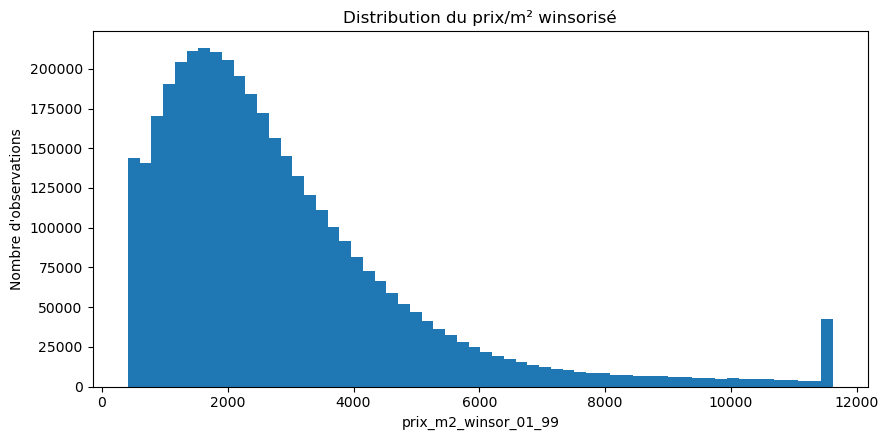

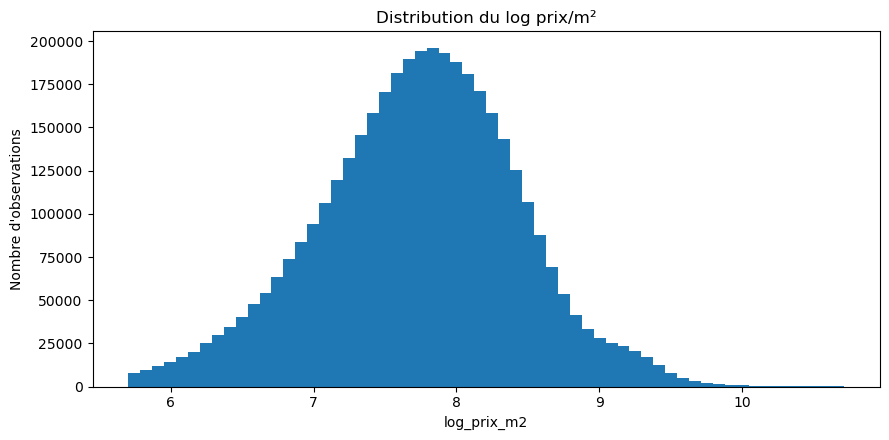

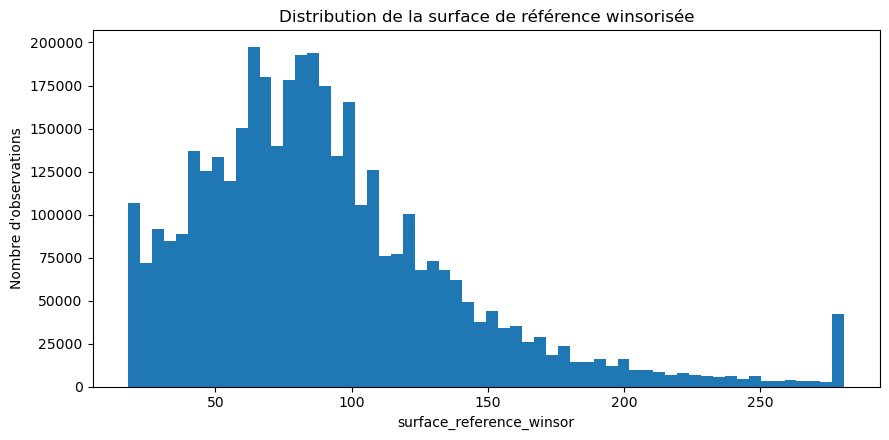

In [14]:
# Histogrammes de distribution pour les trois variables de volume clés
# La version winsorisée est utilisée pour éviter que les extrêmes écrasent la lisibilité
figure_paths.append(plot_hist(df_features["prix_m2_winsor_01_99"], "Distribution du prix/m² winsorisé", "prix_m2_winsor_01_99", filename="hist_prix_m2_winsor_01_99.png"))
figure_paths.append(plot_hist(df_features["log_prix_m2"], "Distribution du log prix/m²", "log_prix_m2", filename="hist_log_prix_m2.png"))
figure_paths.append(plot_hist(df_features["surface_reference_winsor"], "Distribution de la surface de référence winsorisée", "surface_reference_winsor", filename="hist_surface_reference_winsor.png"))


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">La distribution du prix au m² winsorisé conserve une asymétrie positive marquée, caractéristique du marché immobilier résidentiel. La winsorisation réduit l’impact des valeurs extrêmes tout en préservant la structure globale des prix.</h3>
  <div style="color: #4b5563; font-size: 14px;">La transformation logarithmique du prix au m² produit une distribution nettement plus homogène et proche d’une forme gaussienne, facilitant les analyses statistiques et les futurs traitements de modélisation. La distribution de la surface de référence winsorisée reste concentrée sur les surfaces résidentielles standards, avec une majorité de biens situés entre 50 et 120 m². Les grandes surfaces demeurent présentes mais leur influence est désormais mieux contrôlée. Globalement, ces transformations permettent de stabiliser les distributions sans supprimer la diversité économique du marché résidentiel.</div>
</div>

C:\Users\club_\AppData\Local\Temp\ipykernel_31100\2290194760.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=order, showfliers=False)


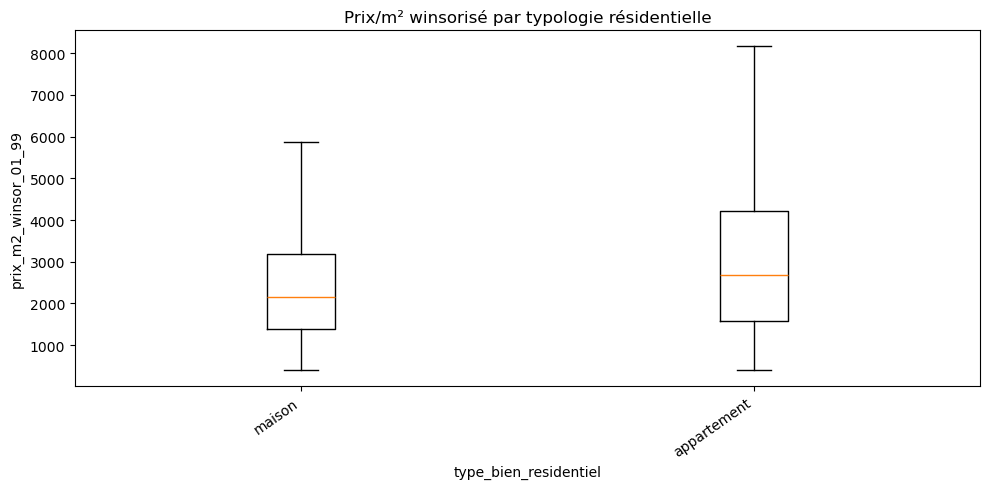

C:\Users\club_\AppData\Local\Temp\ipykernel_31100\2290194760.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=order, showfliers=False)


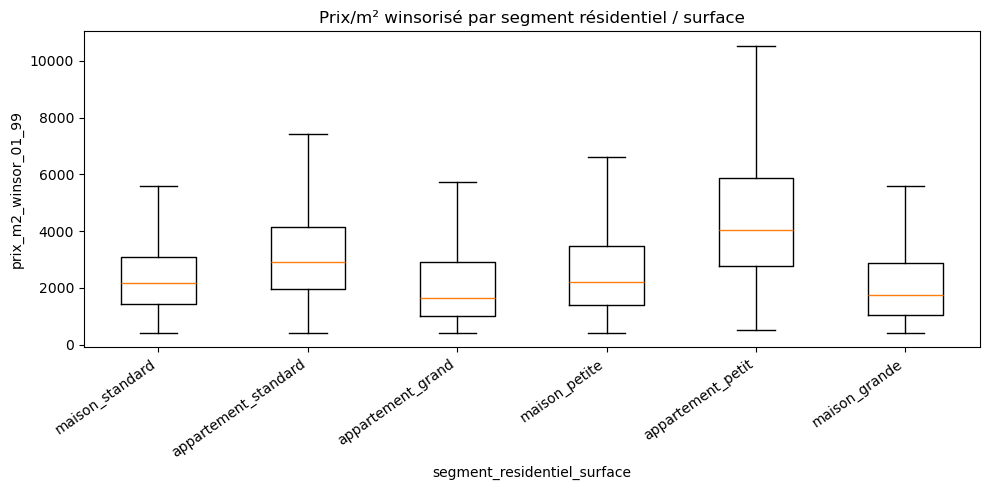

In [15]:
# Boxplot prix/m² par type de bien : compare la médiane et la dispersion entre appartements et maisons
figure_paths.append(plot_box_by_category(
    df_features,
    value_col="prix_m2_winsor_01_99",
    category_col="type_bien_residentiel",
    title="Prix/m² winsorisé par typologie résidentielle",
    filename="box_prix_m2_par_type_bien.png",
))

# Boxplot prix/m² par segment résidentiel × surface : affine la comparaison par gabarit
figure_paths.append(plot_box_by_category(
    df_features,
    value_col="prix_m2_winsor_01_99",
    category_col="segment_residentiel_surface",
    title="Prix/m² winsorisé par segment résidentiel / surface",
    filename="box_prix_m2_par_segment_surface.png",
))


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Les distributions du prix au m² winsorisé confirment des écarts structurels entre maisons et appartements. Les appartements présentent une médiane plus élevée ainsi qu’une dispersion plus importante, traduisant une plus forte hétérogénéité des marchés urbains.</h3>
  <div style="color: #4b5563; font-size: 14px;">La segmentation croisée par type de bien et surface affine cette lecture. Les petits appartements affichent les niveaux de prix au m² les plus élevés, reflet de la forte valorisation des surfaces réduites dans les zones tendues. À l’inverse, les grandes surfaces — maisons comme appartements — présentent des prix unitaires plus modérés, confirmant l’effet décroissant du prix au m² avec l’augmentation de la surface habitable. Les écarts interquartiles observés entre segments mettent également en évidence une forte diversité des configurations résidentielles et des dynamiques territoriales au sein du marché immobilier.</div>
</div>

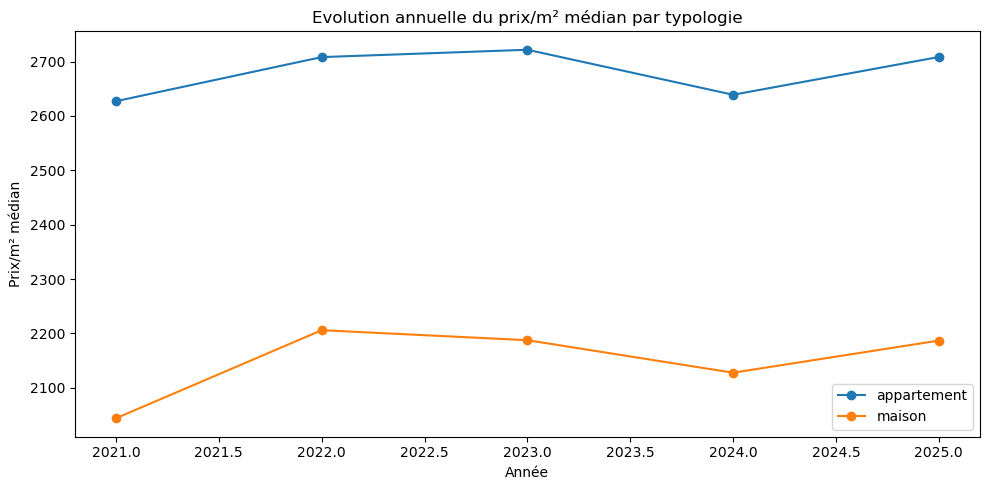

['C:\\Users\\club_\\OneDrive\\13_DOCUMENT\\SYSTEME_AIDE_DECISION_IMMOBILIERE\\outputs\\figures\\hist_prix_m2_winsor_01_99.png',
 'C:\\Users\\club_\\OneDrive\\13_DOCUMENT\\SYSTEME_AIDE_DECISION_IMMOBILIERE\\outputs\\figures\\hist_log_prix_m2.png',
 'C:\\Users\\club_\\OneDrive\\13_DOCUMENT\\SYSTEME_AIDE_DECISION_IMMOBILIERE\\outputs\\figures\\hist_surface_reference_winsor.png',
 'C:\\Users\\club_\\OneDrive\\13_DOCUMENT\\SYSTEME_AIDE_DECISION_IMMOBILIERE\\outputs\\figures\\box_prix_m2_par_type_bien.png',
 'C:\\Users\\club_\\OneDrive\\13_DOCUMENT\\SYSTEME_AIDE_DECISION_IMMOBILIERE\\outputs\\figures\\box_prix_m2_par_segment_surface.png',
 'C:\\Users\\club_\\OneDrive\\13_DOCUMENT\\SYSTEME_AIDE_DECISION_IMMOBILIERE\\outputs\\figures\\line_prix_m2_median_annuel_par_type.png']

In [16]:
# Evolution annuelle médiane prix/m² par type de bien
annual = (
    df_features.dropna(subset=["annee_mutation", "prix_m2", "type_bien_residentiel"])
         .groupby(["annee_mutation", "type_bien_residentiel"])["prix_m2"]
         .median()
         .reset_index()
)

plt.figure(figsize=(10, 5))
for typ, sub in annual.groupby("type_bien_residentiel"):
    if len(sub) >= 2:
        plt.plot(sub["annee_mutation"], sub["prix_m2"], marker="o", label=str(typ))
plt.title("Evolution annuelle du prix/m² médian par typologie")
plt.xlabel("Année")
plt.ylabel("Prix/m² médian")
plt.legend()
figure_paths.append(save_current_figure("line_prix_m2_median_annuel_par_type.png"))

figure_paths = [str(p) for p in figure_paths if p is not None]
figure_paths


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">L’évolution annuelle du prix médian au m² montre une relative stabilité des niveaux de prix entre 2021 et 2025, malgré des fluctuations conjoncturelles du marché immobilier.</h3>
  <div style="color: #4b5563; font-size: 14px;">Les appartements conservent systématiquement un prix au m² supérieur à celui des maisons, avec un écart relativement constant sur l’ensemble de la période. Après une progression observée entre 2021 et 2023, les deux segments enregistrent un léger recul en 2024 avant un redressement en 2025, traduisant une phase d’ajustement puis de stabilisation du marché. La dynamique des appartements apparaît globalement plus stable, tandis que les maisons présentent des variations légèrement plus marquées, potentiellement liées aux évolutions de la demande post-crise sanitaire et aux conditions de financement.</div>
</div>

,variable,nb_non_null,part_non_null,variance
0,prix_m2,3925350,1.000,"5,079,138.229"
1,log_prix_m2,3925350,1.000,0.491
2,surface_reference,3925350,1.000,"2,728.723"
3,log_surface_reference,3925350,1.000,0.317
4,surface_par_piece,3921954,0.999,232.102
5,surface_terrain,1992513,0.508,"483,124,683.386"
6,ratio_terrain_bati,1992513,0.508,"109,315.943"
7,has_dependance,3925350,1.000,0.248
8,mois_depuis_debut,3925350,1.000,308.985


,prix_m2,log_prix_m2,surface_reference,log_surface_reference,surface_par_piece,surface_terrain,ratio_terrain_bati,has_dependance,mois_depuis_debut
prix_m2,1.000,0.875,-0.255,-0.326,-0.182,0.043,0.053,-0.025,0.006
log_prix_m2,0.875,1.000,-0.323,-0.367,-0.257,0.014,0.020,-0.028,0.014
surface_reference,-0.255,-0.323,1.000,0.911,0.560,0.048,-0.014,0.098,-0.001
log_surface_reference,-0.326,-0.367,0.911,1.000,0.455,0.035,-0.027,0.084,-0.002
surface_par_piece,-0.182,-0.257,0.560,0.455,1.000,0.044,0.016,0.226,0.015
surface_terrain,0.043,0.014,0.048,0.035,0.044,1.000,0.766,0.023,-0.000
ratio_terrain_bati,0.053,0.020,-0.014,-0.027,0.016,0.766,1.000,0.009,0.001
has_dependance,-0.025,-0.028,0.098,0.084,0.226,0.023,0.009,1.000,0.044
mois_depuis_debut,0.006,0.014,-0.001,-0.002,0.015,-0.000,0.001,0.044,1.000


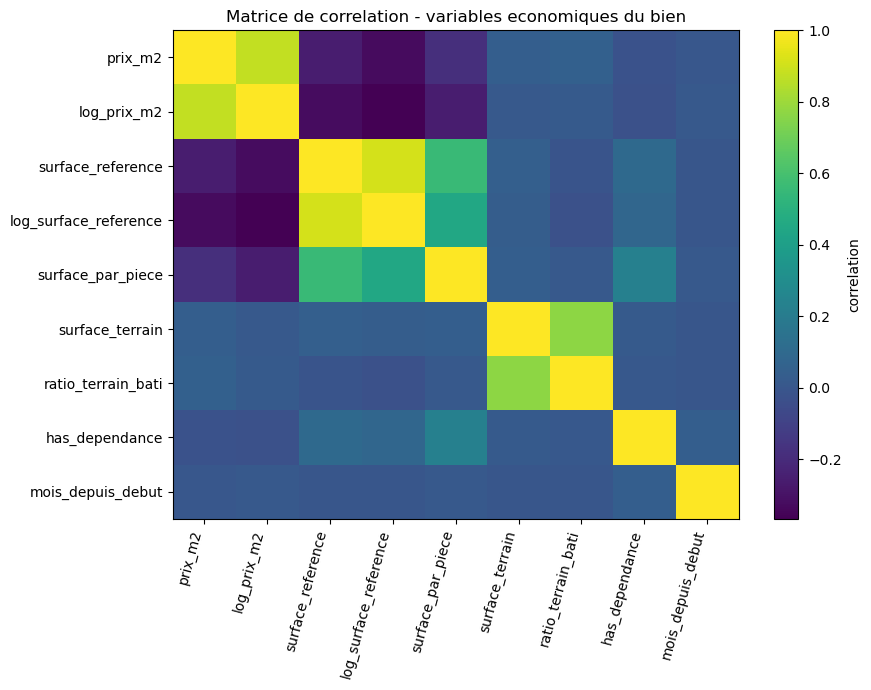

In [ ]:
# Corrélation des variables numériques
# Restreinte aux colonnes numeriques du jeu de features creees (exclut les categorielles et objets)
numeric = df_features[feature_cols_created].select_dtypes(include=[np.number])

# Sous-selection explicite des variables d'interet pour la matrice de correlation
selected_corr_cols = [
    "prix_m2",
    "log_prix_m2",
    "surface_reference",
    "log_surface_reference",
    "surface_par_piece",
    "surface_terrain",
    "ratio_terrain_bati",
    "has_dependance",
    "mois_depuis_debut",
]

# Diagnostic prealable : non-null count et variance pour qualifier la lecture des correlations
corr_input_diagnostic = pd.DataFrame([
    {
        "variable": c,
        "nb_non_null": int(numeric[c].notna().sum()),
        "part_non_null": float(numeric[c].notna().mean()),
        "variance": float(numeric[c].var(skipna=True)) if numeric[c].notna().sum() > 1 else np.nan,
    }
    for c in selected_corr_cols
])

display(corr_input_diagnostic)

# Calcul de la matrice de correlation de Pearson (pairwise, ignore les NaN)
corr = numeric[selected_corr_cols].corr(numeric_only=True)
display(corr)

# Visualisation heatmap via imshow : rapide et sans dependance a seaborn
plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=75, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Matrice de correlation - variables economiques du bien")
figure_paths.append(str(save_current_figure("corr_variables_economiques.png")))


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Cette matrice met en évidence plusieurs relations cohérentes entre les principales variables économiques et foncières du dataset résidentiel.</h3>
  <div style="color: #4b5563; font-size: 14px;">Les variables transformées logarithmiquement restent fortement corrélées à leurs variables d’origine, confirmant que les transformations stabilisent les distributions sans perte majeure d’information. Une corrélation négative modérée apparaît entre le prix au m² et la surface du bien, phénomène classique du marché résidentiel où les petites surfaces présentent généralement des prix unitaires plus élevés. Les variables foncières liées au terrain présentent des corrélations cohérentes entre elles, traduisant une bonne stabilité des indicateurs construits. La présence de dépendances est également davantage associée aux biens de grande surface, ce qui reflète des configurations résidentielles plus étendues. Ces corrélations doivent toutefois être interprétées avec prudence. À ce stade du projet, la matrice constitue principalement un outil d’exploration et de compréhension des structures de données, sans objectif immédiat de sélection définitive des variables.</div>
</div>

In [18]:
# Construction du dictionnaire de variables : dédoublonnage sur le nom (on garde la dernière déclaration)
# puis tri par usage/famille/variable pour une lecture métier cohérente
variable_dictionary = pd.DataFrame(feature_registry).drop_duplicates(subset=["variable"], keep="last")
variable_dictionary = variable_dictionary.sort_values(["usage", "famille", "variable"]).reset_index(drop=True)

display(variable_dictionary)

# Extraction des listes de variables par catégorie d'usage (utilisées pour construire les vues export)
id_join_features = variable_dictionary.loc[variable_dictionary["usage"].eq("id_join"), "variable"].tolist()
target_features = variable_dictionary.loc[variable_dictionary["usage"].eq("target"), "variable"].tolist()
eda_only_features = variable_dictionary.loc[variable_dictionary["usage"].eq("eda_only"), "variable"].tolist()
model_safe_raw_features = variable_dictionary.loc[variable_dictionary["usage"].eq("model_safe_raw"), "variable"].tolist()
model_safe_after_train_transform_features = variable_dictionary.loc[variable_dictionary["usage"].eq("model_safe_after_train_transform"), "variable"].tolist()

# Résumé du nombre de variables par catégorie d'usage
classification_summary = variable_dictionary["usage"].value_counts().rename_axis("usage").reset_index(name="nb_variables")
display(classification_summary)

print(f"Variables model-safe raw : {len(model_safe_raw_features)}")
print(f"Variables à transformer en apprenant les paramètres sur train : {len(model_safe_after_train_transform_features)}")
print(f"Variables EDA only : {len(eda_only_features)}")
print(f"Variables target : {len(target_features)}")


,variable,famille,description,usage,model_safe_raw,train_transform_required,leakage_risk,source
0,prix_m2_winsor_01_99,cible_transformée,Prix/m² winsorisé pour diagnostics robustes,eda_only,False,False,cible,créée 00_03
1,id_mutation,identifiant,Identifiant mutation stabilise,id_join,False,False,aucun,créée 00_03
2,date_mutation,temps,Date de mutation normalisee,id_join,False,False,faible,heritee 00_02
3,surface_reference_winsor,surface,Surface winsorisee 1%-99% pour diagnostics ; r...,model_safe_after_train_transform,False,True,moyen,créée 00_03
4,classe_surface,surface,Classe de surface interpretable,model_safe_raw,True,False,faible,créée 00_03
5,log_surface_reference,surface,Log de la surface de reference,model_safe_raw,True,False,faible,créée 00_03
6,nb_pieces_total,surface,Nombre total de pieces,model_safe_raw,True,False,faible,créée 00_03
7,pieces_info_disponible,surface,Flag indiquant si l'information pieces est dis...,model_safe_raw,True,False,faible,créée 00_03
8,surface_par_piece,surface,Surface moyenne par piece,model_safe_raw,True,False,faible,créée 00_03
9,surface_reference,surface,Surface economique de reference heritee du 00_02,model_safe_raw,True,False,faible,heritee 00_02


,usage,nb_variables
0,model_safe_raw,26
1,target,4
2,id_join,2
3,eda_only,1
4,model_safe_after_train_transform,1


Variables model-safe raw : 26
Variables à transformer en apprenant les paramètres sur train : 1
Variables EDA only : 1
Variables target : 4


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Commentaires sur le dictionnaire de variables et leur statut</h3>
  <div style="color: #4b5563; font-size: 14px;">Cette table formalise le rôle analytique et méthodologique de chaque variable construite dans le notebook. Elle constitue à la fois un dictionnaire métier, une documentation technique et un outil de contrôle pour les futures phases de modélisation. L’organisation par familles de variables améliore la lisibilité du pipeline et permet de distinguer clairement les variables explicatives, les variables exploratoires, les identifiants techniques et les variables cibles. La colonne `usage` précise le statut opérationnel de chaque variable : target` : variable cible du modèle ; model_safe_raw` : variable directement exploitable ; model_safe_after_train_transform` : variable nécessitant une transformation calculée uniquement sur le train ; eda_only` : variable réservée à l’analyse exploratoire. Cette structuration permet d’anticiper les principaux risques de fuite de données (`data leakage`) lors des futures étapes de modélisation. La colonne `leakage_risk` apporte un niveau supplémentaire de gouvernance en identifiant les variables sensibles aux transformations globales ou directement liées à la cible. Les variables `prix_m2`, `log_prix_m2` et `valeur_fonciere` sont ainsi correctement classées comme variables cibles, tandis que `surface_reference_winsor` est identifiée comme nécessitant un recalcul limité au jeu d’entraînement. À l’inverse, des variables métiers comme `classe_surface`, `surface_par_piece` ou `ratio_terrain_bati` restent directement exploitables avec un risque limité. Le tableau met également en évidence une bonne maturité méthodologique du projet : nomenclature cohérente des variables ; traçabilité des variables héritées et créées ; documentation des transformations ; anticipation des usages analytiques et ML. Cette documentation constitue enfin un véritable cadre de gouvernance des features entre exploration, préparation des données et modélisation future.</div>
</div>

In [ ]:
# Constitution du jeu de sortie
# 
# Colonnes d'identification minimales pour jointure et audit (non explicatives)
id_cols = ["id_mutation", "date_mutation"]

# Colonnes cibles exportees separement pour eviter toute contamination du jeu modele
target_cols = ["prix_m2", "log_prix_m2", "valeur_fonciere", "surface_reference"]

# Variables model-safe raw : on exclut les id_cols deja inclus pour eviter les doublons
model_raw_cols = [c for c in model_safe_raw_features if c not in id_cols]

# Variables necessitant une transformation apprise sur train (winsorisees, etc.)
train_transform_cols = model_safe_after_train_transform_features

# Construction des quatre vues distinctes du dataset
# Les ids sont toujours inclus pour permettre les jointures, mais pas comme features explicatives
df_model_safe_raw = df_features[id_cols + model_raw_cols].copy()
df_model_train_transform_required = df_features[id_cols + train_transform_cols].copy()
df_target = df_features[id_cols + target_cols].copy()

# Alias de compatibilite avec les notebooks aval qui referencent l'ancien nom d'export
df_model_candidates = df_model_safe_raw.copy()

print("Full:", df_features.shape)
print("Model safe raw:", df_model_safe_raw.shape)
print("Train-transform required:", df_model_train_transform_required.shape)
print("Target:", df_target.shape)


Full: (3925350, 86)
Model safe raw: (3925350, 28)
Train-transform required: (3925350, 3)
Target: (3925350, 6)


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Sécurisation du schéma</h3>
  <div style="color: #4b5563; font-size: 14px;">La suppression contrôlée des colonnes dupliquées protège les exports contre les ambiguïtés de nommage. Ce contrôle est particulièrement utile lorsque des variables héritées et créées peuvent partager une même dénomination.</div>
</div>

In [ ]:
# suppression contrôlée des colonnes dupliquées protège les exports contre les ambiguïtés de nommage. 
# Ce contrôle est particulièrement utile lorsque des variables héritées et créées peuvent partager une même dénomination.

def remove_duplicate_columns(df, df_name):
    """Supprime les colonnes en double d'un DataFrame et affiche un rapport.
    Des doublons peuvent apparaître si une colonne héritée et une colonne créée portent le même nom."""
    duplicated_cols = df.columns[df.columns.duplicated()].tolist()

    if duplicated_cols:
        print(f"{df_name} - colonnes dupliquées supprimées :", duplicated_cols)
        # keep=False marque toutes les occurrences ; ~duplicated() garde la première
        df = df.loc[:, ~df.columns.duplicated()].copy()
    else:
        print(f"{df_name} - aucune colonne dupliquée")

    return df


# Application sur tous les DataFrames exportés pour garantir des schémas propres
df_features = remove_duplicate_columns(df_features, "df_features")
df_model_candidates = remove_duplicate_columns(df_model_candidates, "df_model_candidates")
df_target = remove_duplicate_columns(df_target, "df_target")
df_model_safe_raw = remove_duplicate_columns(df_model_safe_raw, "df_model_safe_raw")
df_model_train_transform_required = remove_duplicate_columns(df_model_train_transform_required, "df_model_train_transform_required")


df_features - aucune colonne dupliquée
df_model_candidates - aucune colonne dupliquée
df_target - aucune colonne dupliquée
df_model_safe_raw - aucune colonne dupliquée
df_model_train_transform_required - aucune colonne dupliquée


In [ ]:
# Export
# Définition des chemins de sortie.
# La sortie principale alimente le notebook suivant.
# Les sorties complémentaires documentent les usages possibles des variables.

OUTPUT_PATH = PATHS["processed"] / "df_biens_residentiels_variables.parquet"
OUTPUT_MODEL_SAFE_RAW_PATH = PATHS["processed"] / "df_biens_residentiels_variables_model_safe_raw.parquet"
OUTPUT_MODEL_CANDIDATES_PATH = PATHS["processed"] / "df_biens_residentiels_variables_model_candidates.parquet"
OUTPUT_TRAIN_TRANSFORM_PATH = PATHS["processed"] / "df_biens_residentiels_variables_train_transform_required.parquet"
OUTPUT_TARGET_PATH = PATHS["processed"] / "df_biens_residentiels_variables_target.parquet"
OUTPUT_SAMPLE_PATH = PATHS["processed"] / "df_biens_residentiels_variables_sample.csv"

# Rapports de qualité et documentation des variables.
OUTPUT_DICT_PATH = PATHS["reports"] / "dictionnaire_variables_bien.csv"
OUTPUT_QUALITY_PATH = PATHS["reports"] / "rapport_qualite_variables_bien.csv"
OUTPUT_MISSING_PATH = PATHS["reports"] / "missing_report_variables_bien.csv"
OUTPUT_CLASSIFICATION_PATH = PATHS["reports"] / "classification_usage_variables_bien.csv"
OUTPUT_WINSOR_PATH = PATHS["reports"] / "winsor_params_diagnostic_variables_bien.json"
OUTPUT_MANIFEST_PATH = PATHS["reports"] / "manifest_variables_bien.json"

# Alias historiques conservés pour limiter l'impact sur le reste du notebook.
output_full = OUTPUT_PATH
output_model_raw = OUTPUT_MODEL_SAFE_RAW_PATH
output_model = OUTPUT_MODEL_CANDIDATES_PATH
output_train_transform = OUTPUT_TRAIN_TRANSFORM_PATH
output_target = OUTPUT_TARGET_PATH
output_sample = OUTPUT_SAMPLE_PATH
output_dict = OUTPUT_DICT_PATH
output_quality = OUTPUT_QUALITY_PATH
output_missing = OUTPUT_MISSING_PATH
output_classification = OUTPUT_CLASSIFICATION_PATH
output_winsor = OUTPUT_WINSOR_PATH
output_manifest = OUTPUT_MANIFEST_PATH

# Exports parquet.
df_features.to_parquet(OUTPUT_PATH, index=False)
df_model_safe_raw.to_parquet(OUTPUT_MODEL_SAFE_RAW_PATH, index=False)
df_model_candidates.to_parquet(OUTPUT_MODEL_CANDIDATES_PATH, index=False)
df_model_train_transform_required.to_parquet(OUTPUT_TRAIN_TRANSFORM_PATH, index=False)
df_target.to_parquet(OUTPUT_TARGET_PATH, index=False)

# Échantillon CSV : tirage aléatoire reproductible de 10 000 lignes max pour inspection externe.
df_features.sample(min(10_000, len(df_features)), random_state=42).to_csv(OUTPUT_SAMPLE_PATH, index=False)

# Exports rapports CSV.
variable_dictionary.to_csv(OUTPUT_DICT_PATH, index=False)
quality_report.to_csv(OUTPUT_QUALITY_PATH, index=False)
missing_report.to_csv(OUTPUT_MISSING_PATH, index=False)
classification_summary.to_csv(OUTPUT_CLASSIFICATION_PATH, index=False)

# Export des paramètres de winsorisation (JSON).
# Permet de réappliquer exactement les mêmes bornes pour la documentation ou debug.
with open(OUTPUT_WINSOR_PATH, "w", encoding="utf-8") as f:
    json.dump(winsor_params, f, ensure_ascii=False, indent=2)

# Construction du manifest de run.
# Résumé chiffré des outputs pour traçabilité et intégration pipeline.
final_summary = {
    "n_rows": int(len(df_features)),
    "n_columns_full": int(df_features.shape[1]),
    "n_model_safe_raw_columns": int(df_model_safe_raw.shape[1]),
    "n_train_transform_required_columns": int(df_model_train_transform_required.shape[1]),
    "n_target_columns": int(df_target.shape[1]),
    "n_features_documented": int(len(variable_dictionary)),
    "n_quality_warnings": int((quality_report["status"] == "WARNING").sum()),
    "n_quality_errors": int((quality_report["status"] == "ERROR").sum()),
    "max_missing_rate": float(missing_report["taux_missing"].max()) if not missing_report.empty else None,
}

manifest = {
    "notebook": "03_definition_variables_bien",
    "run_timestamp": RUN_TIMESTAMP,
    "input": str(INPUT_PATH),
    "outputs": {
        "full": str(OUTPUT_PATH),
        "model_safe_raw": str(OUTPUT_MODEL_SAFE_RAW_PATH),
        "model_candidates": str(OUTPUT_MODEL_CANDIDATES_PATH),
        "train_transform_required": str(OUTPUT_TRAIN_TRANSFORM_PATH),
        "target": str(OUTPUT_TARGET_PATH),
        "sample": str(OUTPUT_SAMPLE_PATH),
        "dictionary": str(OUTPUT_DICT_PATH),
        "quality_report": str(OUTPUT_QUALITY_PATH),
        "missing_report": str(OUTPUT_MISSING_PATH),
        "classification_summary": str(OUTPUT_CLASSIFICATION_PATH),
        "winsor_params_diagnostic": str(OUTPUT_WINSOR_PATH),
        "figures": figure_paths,
    },
    "summary": final_summary,
    "anti_leakage_note": "Les variables winsorisées sont exportées pour diagnostic mais exclues de model_safe_raw. Si utilisées en modèle, recalculer les seuils sur le train uniquement.",
    "created_from": "02_nettoyage_residentiel",
}

# Sérialisation du manifest en JSON UTF-8.
with open(OUTPUT_MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

print("Exports réalisés :")
for k, v in manifest["outputs"].items():
    print(f"- {k}: {v}")

print("\nRésumé final :")
display(pd.DataFrame([final_summary]).T.rename(columns={0: "valeur"}))

Exports réalisés :
- full: C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_biens_residentiels_variables.parquet
- model_safe_raw: C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_biens_residentiels_variables_model_safe_raw.parquet
- model_candidates: C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_biens_residentiels_variables_model_candidates.parquet
- train_transform_required: C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_biens_residentiels_variables_train_transform_required.parquet
- target: C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_biens_residentiels_variables_target.parquet
- sample: C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_biens_residentiels_variables_sample.csv
- dictionary: C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISIO

,valeur
n_rows,"3,925,350.000"
n_columns_full,86.000
n_model_safe_raw_columns,28.000
n_train_transform_required_columns,3.000
n_target_columns,6.000
n_features_documented,34.000
n_quality_warnings,0.000
n_quality_errors,0.000
max_missing_rate,1.000


Aucun fond départemental trouvé : reconstitution des départements depuis l'IRIS.
Jointure géographique : 5 département(s) sans données : ['57', '67', '68', '977', '978']
Départements conservés pour la carte France :
['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '21', '22', '23', '24', '25', '26', '27', '28', '29', '2A', '2B', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95']
Départements exclus :
['971', '972', '973', '974', '977', '978']


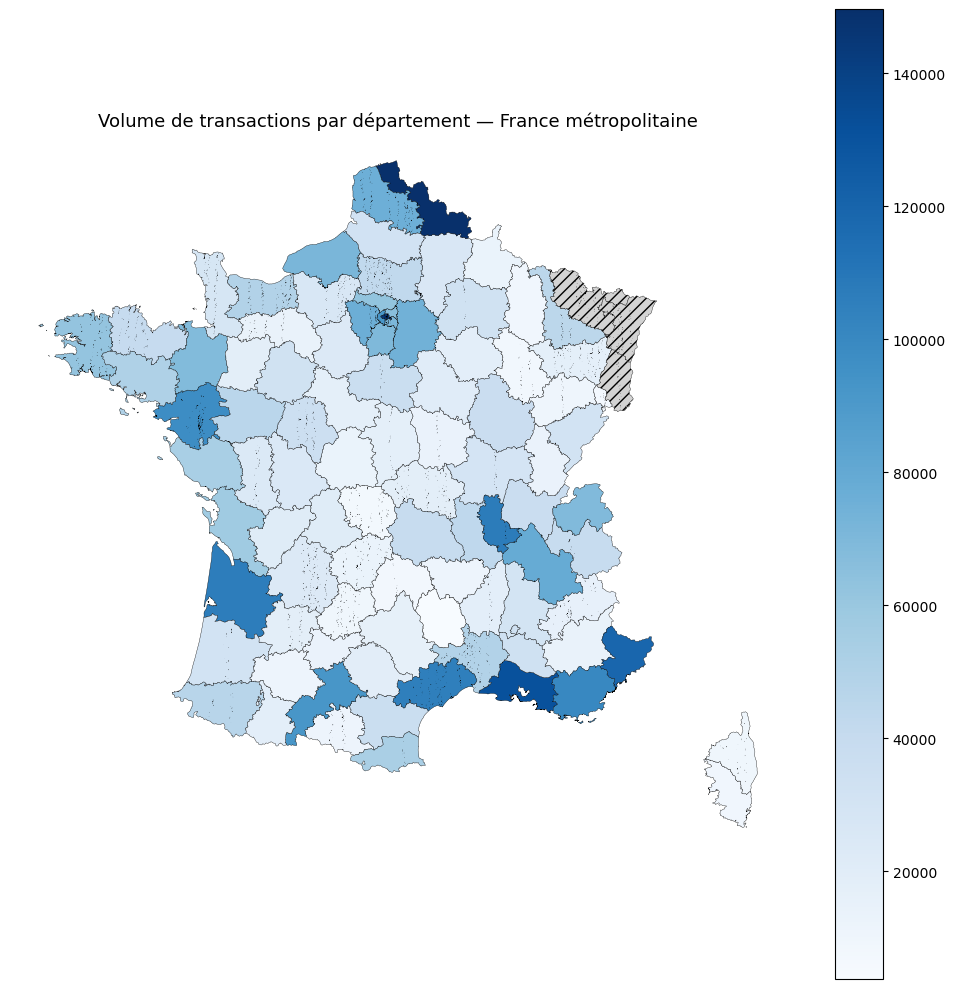

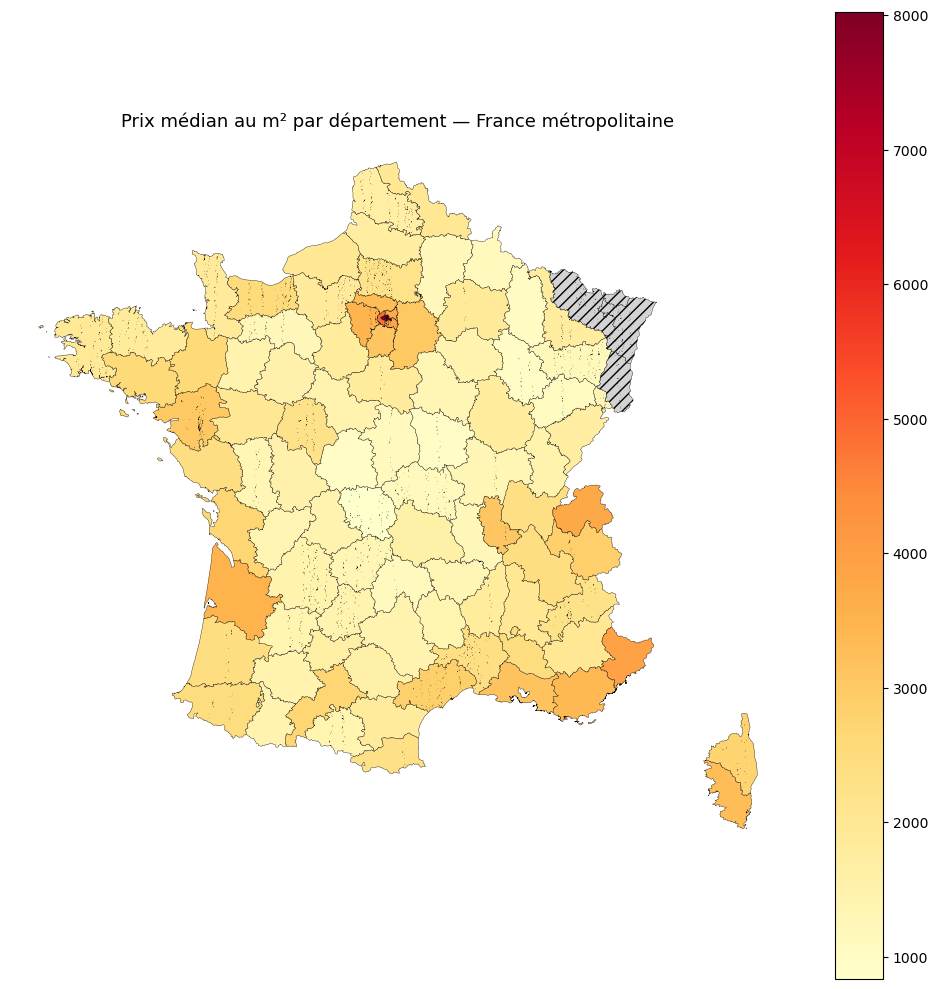

Source : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_biens_residentiels_variables.parquet
Carte volume France métropolitaine : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\figures\03_cartographie_volume_transactions_france_metropolitaine.png
Carte prix France métropolitaine : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\figures\03_cartographie_prix_m2_france_metropolitaine.png


In [ ]:
# Cartographielimité à la France métropolitaine dans un premeir temps en vue d'un contrôle spatial de la couverture des données et contrastes territoriaux

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

NOTEBOOK_TAG = "03"
EXTERNAL_DIR = PROJECT_ROOT / "data" / "external"
FIG_DIR = PATHS["figures"]
FIG_DIR.mkdir(parents=True, exist_ok=True)

candidates = [
    PATHS["processed"] / "df_biens_residentiels_variables.parquet",
    PATHS["processed"] / "df_biens_residentiels_territoire.parquet",
    PATHS["processed"] / "df_biens_residentiels_iris.parquet",
]

source_path = next((p for p in candidates if p.exists()), None)
if source_path is None:
    raise FileNotFoundError("Aucun parquet trouvé pour la cartographie.")

df_carto = pd.read_parquet(source_path)

if "code_departement" not in df_carto.columns:
    raise ValueError("La colonne code_departement est absente du jeu source.")

df_carto = df_carto.copy()
df_carto["code_departement"] = df_carto["code_departement"].apply(normalize_code_departement)

if "prix_m2" in df_carto.columns:
    price_col = "prix_m2"
elif "prix_m2_model" in df_carto.columns:
    price_col = "prix_m2_model"
else:
    price_col = None

agg_dict = {"n_transactions": ("code_departement", "size")}

if price_col is not None:
    agg_dict["prix_m2_median"] = (price_col, "median")

agg_dept = (
    df_carto
    .dropna(subset=["code_departement"])
    .groupby("code_departement", dropna=True)
    .agg(**agg_dict)
    .reset_index()
)

agg_dept["code_departement"] = agg_dept["code_departement"].apply(normalize_code_departement)

gdf_dept = load_department_geometries(EXTERNAL_DIR)
gdf_dept = gdf_dept.copy()
gdf_dept["code_departement"] = gdf_dept["code_departement"].apply(normalize_code_departement)

gdf_plot = gdf_dept.merge(
    agg_dept,
    on="code_departement",
    how="left"
)

missing_geo = report_geo_join_quality(gdf_plot, value_col="n_transactions")

METRO_CODES = (
    [f"{i:02d}" for i in range(1, 96) if i != 20]
    + ["2A", "2B"]
)

gdf_france = gdf_plot[
    gdf_plot["code_departement"].isin(METRO_CODES)
].copy()

print("Départements conservés pour la carte France :")
print(sorted(gdf_france["code_departement"].dropna().unique()))

print("Départements exclus :")
print(sorted(set(gdf_plot["code_departement"].dropna()) - set(gdf_france["code_departement"].dropna())))

try:
    gdf_france = gdf_france.to_crs(epsg=2154)
except Exception as e:
    print(f"Projection EPSG:2154 non appliquée : {e}")


def plot_france_metropolitaine(gdf, column, title, output_path, cmap):
    fig, ax = plt.subplots(figsize=(10, 10))

    gdf.plot(
        column=column,
        cmap=cmap,
        legend=True,
        edgecolor="black",
        linewidth=0.25,
        missing_kwds={
            "color": "lightgrey",
            "edgecolor": "black",
            "hatch": "///",
            "label": "Sans données",
        },
        ax=ax,
    )

    ax.set_title(title, fontsize=13)
    ax.axis("off")

    minx, miny, maxx, maxy = gdf.total_bounds
    marge_x = (maxx - minx) * 0.04
    marge_y = (maxy - miny) * 0.04

    ax.set_xlim(minx - marge_x, maxx + marge_x)
    ax.set_ylim(miny - marge_y, maxy + marge_y)

    plt.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()


out_volume_france = FIG_DIR / f"{NOTEBOOK_TAG}_cartographie_volume_transactions_france_metropolitaine.png"

plot_france_metropolitaine(
    gdf_france,
    column="n_transactions",
    title="Volume de transactions par département — France métropolitaine",
    output_path=out_volume_france,
    cmap="Blues",
)

if "prix_m2_median" in gdf_france.columns:
    out_price_france = FIG_DIR / f"{NOTEBOOK_TAG}_cartographie_prix_m2_france_metropolitaine.png"

    plot_france_metropolitaine(
        gdf_france,
        column="prix_m2_median",
        title="Prix médian au m² par département — France métropolitaine",
        output_path=out_price_france,
        cmap="YlOrRd",
    )

print(f"Source : {source_path}")
print(f"Carte volume France métropolitaine : {out_volume_france}")

if "prix_m2_median" in gdf_france.columns:
    print(f"Carte prix France métropolitaine : {out_price_france}")
else:
    print("Carte prix France métropolitaine : non générée.")

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Commentaires — lecture croisée des cartes départementales</h3>
  <div style="color: #4b5563; font-size: 14px;">Ces cartes proposent une lecture complémentaire du marché immobilier français à travers le volume de transactions et le prix médian au m² par département. Leur comparaison met en évidence une dissociation nette entre l’intensité de l’activité immobilière et le niveau des prix. Les départements les plus actifs ne correspondent pas systématiquement aux territoires les plus valorisés. Les volumes de mutations se concentrent principalement dans les zones fortement urbanisées, les grandes métropoles régionales et certains territoires littoraux attractifs. À l’inverse, les prix médians les plus élevés apparaissent surtout en Île-de-France, sur le littoral méditerranéen et dans plusieurs zones touristiques ou à forte tension foncière. Cette lecture territoriale souligne la forte hétérogénéité du marché résidentiel français et confirme l’importance des dynamiques locales dans la formation des prix immobiliers.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture spécifique DROM</h3>
  <div style="color: #4b5563; font-size: 14px;">Les DROM sont isolés dans une carte dédiée afin d’éviter une représentation illisible à l’échelle métropolitaine. Cette séparation améliore la lisibilité tout en conservant la couverture nationale du projet.</div>
</div>

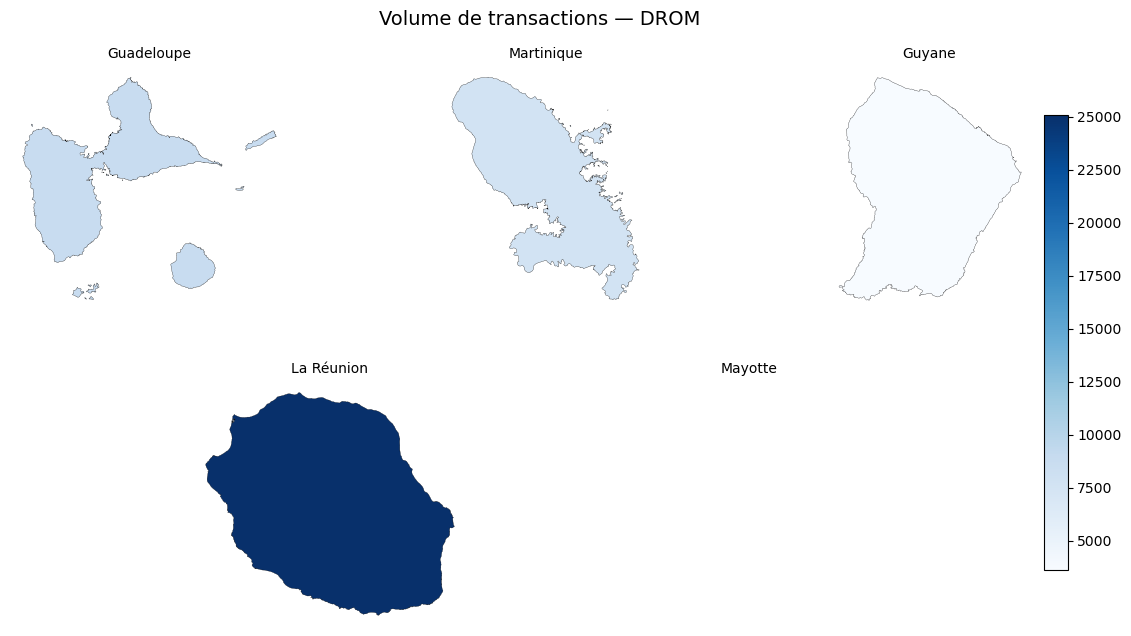

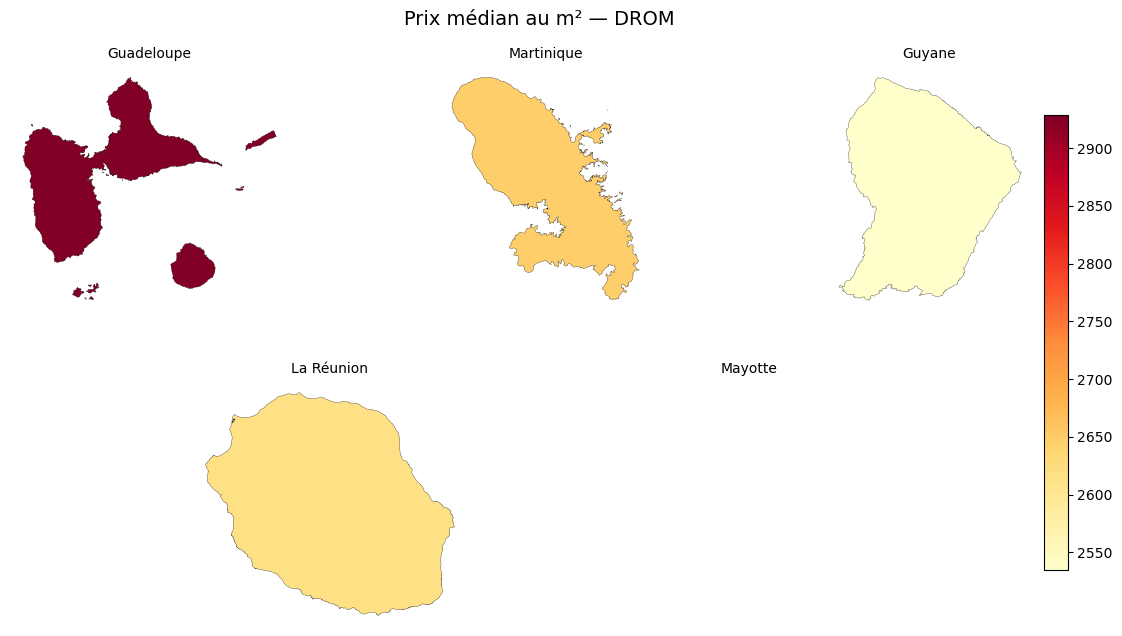

Carte volume DROM : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\figures\03_cartographie_volume_transactions_drom.png
Carte prix DROM : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\figures\03_cartographie_prix_m2_drom.png


In [23]:
#  Cartographie DROM uniquement

DROM_CODES = ["971", "972", "973", "974", "976"]

gdf_drom = gdf_plot[
    gdf_plot["code_departement"].isin(DROM_CODES)
].copy()


def plot_drom(gdf, column, title, output_path, cmap):
    droms = {
        "Guadeloupe": "971",
        "Martinique": "972",
        "Guyane": "973",
        "La Réunion": "974",
        "Mayotte": "976",
    }

    gdf = gdf.copy()

    if column not in gdf.columns:
        raise ValueError(f"Colonne absente du GeoDataFrame : {column}")

    vmin = gdf[column].min(skipna=True)
    vmax = gdf[column].max(skipna=True)

    fig = plt.figure(figsize=(12, 7))

    axes = {
        "Guadeloupe": fig.add_axes([0.05, 0.55, 0.25, 0.35]),
        "Martinique": fig.add_axes([0.38, 0.55, 0.25, 0.35]),
        "Guyane": fig.add_axes([0.70, 0.55, 0.25, 0.35]),
        "La Réunion": fig.add_axes([0.20, 0.10, 0.25, 0.35]),
        "Mayotte": fig.add_axes([0.55, 0.10, 0.25, 0.35]),
    }

    plot_kwargs = dict(
        column=column,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        edgecolor="black",
        linewidth=0.2,
        missing_kwds={
            "color": "lightgrey",
            "edgecolor": "black",
            "hatch": "///",
            "label": "Sans données",
        },
    )

    for name, code in droms.items():
        ax = axes[name]
        subset = gdf[gdf["code_departement"] == code]

        if not subset.empty:
            subset.plot(ax=ax, **plot_kwargs)

        ax.set_title(name, fontsize=10)
        ax.axis("off")

    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(vmin=vmin, vmax=vmax),
    )
    sm._A = []

    cbar_ax = fig.add_axes([0.92, 0.18, 0.02, 0.65])
    fig.colorbar(sm, cax=cbar_ax)

    fig.suptitle(title, fontsize=14, y=0.98)
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()


out_volume_drom = FIG_DIR / f"{NOTEBOOK_TAG}_cartographie_volume_transactions_drom.png"

plot_drom(
    gdf_drom,
    column="n_transactions",
    title="Volume de transactions — DROM",
    output_path=out_volume_drom,
    cmap="Blues",
)

if "prix_m2_median" in gdf_drom.columns:
    out_price_drom = FIG_DIR / f"{NOTEBOOK_TAG}_cartographie_prix_m2_drom.png"

    plot_drom(
        gdf_drom,
        column="prix_m2_median",
        title="Prix médian au m² — DROM",
        output_path=out_price_drom,
        cmap="YlOrRd",
    )

print(f"Carte volume DROM : {out_volume_drom}")

if "prix_m2_median" in gdf_drom.columns:
    print(f"Carte prix DROM : {out_price_drom}")
else:
    print("Carte prix DROM : non générée.")

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Commentaires — lecture croisée des DROM</h3>
  <div style="color: #4b5563; font-size: 14px;">Ces cartes étendent l’analyse territoriale aux DROM, dont les dynamiques immobilières diffèrent sensiblement de celles observées en métropole. La Réunion concentre le volume de transactions le plus élevé, traduisant un marché résidentiel plus dense et plus actif que dans les autres territoires ultramarins. À l’inverse, la Guyane et Mayotte présentent des volumes nettement plus faibles, reflétant des marchés plus restreints ou une couverture DVF plus limitée. Les écarts de prix médians au m² montrent également une forte hétérogénéité entre territoires. La Guadeloupe apparaît comme le marché le plus valorisé parmi les DROM représentés, devant la Martinique et La Réunion. Ces différences peuvent s’expliquer par la rareté foncière, les contraintes géographiques, les coûts de construction et les dynamiques locales de demande. La comparaison des deux cartes confirme enfin qu’un marché peut rester relativement peu volumineux tout en affichant des niveaux de prix élevés. Les volumes de transactions et les prix au m² décrivent donc des réalités économiques complémentaires mais distinctes.</div>
</div>